# Week 2 - Exploratory Data Analysis (EDA) & Visualization

---

<img src="https://img1.picmix.com/output/stamp/normal/2/3/3/1/2231332_62925.gif" alt="Ganbatte" style="width:5px;height:5px;">

```
Apa itu Exploratory Data Analysis (EDA)?
```

Metode yang digunakan oleh data scientist untuk **menganalisis dan menyelidiki dataset** serta **merangkum karakteristik utamanya**, sering kali dengan bantuan teknik visualisasi data



<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250806130212782461/file.webp">

Sumber: https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/

<img src="https://www.edureka.co/blog/wp-content/uploads/2018/08/Insurance-Leadspace-Aniamted.gif" alt="Data Analytics" width=800>

## Import Libraries

Library utama yang kita gunakan adalah `matplotlib` dan `seaborn`, dua library ini adalah library esensial dalam eksplorasi dan visualisasi data yang paling umum. `plotly` juga merupakan library populer untuk visualisasi yang interaktif.

In [1]:
# instalasi library jika belum terinstall. Jika menggunakan Google Colab maka ignore saja karena sudah terinstall.

# !pip install matplotlib seaborn plotly

In [2]:
# Untuk generate angka random dengan studi kasus tertentu
import numpy as np

# Dataframe
import pandas as pd

# Lib visualisasi well-known & praktis
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# Lib statistikal
import scipy.stats as stats

# Dataset sample
from sklearn.datasets import load_iris

# Preprocessing with python lib
from sklearn.impute import SimpleImputer

## Exploratory Data Analysis

![iris flower](https://raw.githubusercontent.com/Masterx-AI/Project_Horse_Sruvival_Prognostication/main/horse.jpg)

Dataset Goals : Untuk prediksi apakah seekor kuda akan selamat atau tidak berdasarkan kondisi-kondisi medis tertentu.<br>
sauce : https://www.kaggle.com/datasets/yasserh/horse-survival-dataset

Jika kalian menggunakan Colab, bisa menggunakan link ini sebagai alternatif file:

- https://raw.githubusercontent.com/Pieter414/BCC-EDA/refs/heads/main/aapl_stock_price.csv (AAPL Stock Price)
- https://raw.githubusercontent.com/Pieter414/BCC-EDA/refs/heads/main/predict-horses-health.csv (Horse Survival Dataset)


In [3]:
# load data quda
horse_health_data = pd.read_csv(
    "https://raw.githubusercontent.com/Pieter414/BCC-EDA/refs/heads/main/predict-horses-health.csv",
    delimiter=","
)
horse_health_data.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


# W/o Visualization

## Recap Materi Minggu 1 (Overview dan Eksplorasi Data Awal)


In [4]:
# .info(): berikan saya informasi struktural data (kolom, jumlah baris, tipe data dkk)
horse_health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

Kita menemukan bahwa kolom target berupa kolom kategorikal dengan nama `outcome`

In [5]:
# .head(): Melihat X (default=5) data teratas
horse_health_data.head(5)

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [6]:
# .tail(): Melihat X (default=5) data terbawah
horse_health_data.tail(5)

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
1230,1230,yes,adult,535246,38.5,129.0,48.0,cool,reduced,pale_pink,...,57.0,66.0,serosanguious,2.0,yes,2206,0,0,no,lived
1231,1231,yes,adult,528570,37.5,60.0,50.0,cool,reduced,pale_cyanotic,...,35.0,6.4,serosanguious,3.6,yes,2209,0,0,yes,died
1232,1232,yes,young,529685,37.5,84.0,40.0,normal,reduced,normal_pink,...,40.0,5.9,cloudy,7.0,yes,400,0,0,yes,lived
1233,1233,yes,adult,534784,38.1,70.0,16.0,normal,reduced,bright_red,...,58.0,74.0,cloudy,2.0,yes,2209,0,0,no,lived
1234,1234,yes,adult,528548,38.1,54.0,36.0,normal,normal,pale_pink,...,45.0,6.0,clear,3.6,yes,2124,0,0,yes,lived


In [7]:
# .describe(): Simple Descriptive Statistics
horse_health_data.describe()

,id,hospital_number,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
count,1235.0000,1.235000e+03,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,617.0000,9.545004e+05,38.202186,79.574089,30.054251,4.382591,49.602429,21.388016,3.290931,3832.496356,14.612146,3.577328
std,356.6581,1.356403e+06,0.788668,29.108638,16.452066,1.937357,10.535800,26.676453,1.589195,5436.733774,193.705735,88.858953
min,0.0000,5.213990e+05,35.400000,30.000000,8.000000,1.000000,23.000000,3.500000,0.100000,0.000000,0.000000,0.000000
25%,308.5000,5.288000e+05,37.800000,53.000000,18.000000,2.000000,43.000000,6.600000,2.000000,2205.000000,0.000000,0.000000
50%,617.0000,5.297770e+05,38.200000,76.000000,28.000000,4.500000,48.000000,7.500000,3.000000,2209.000000,0.000000,0.000000
75%,925.5000,5.341450e+05,38.600000,100.000000,36.000000,6.000000,57.000000,9.100000,4.300000,3205.000000,0.000000,0.000000
max,1234.0000,5.305129e+06,40.800000,184.000000,96.000000,7.500000,75.000000,89.000000,10.100000,41110.000000,3112.000000,2209.000000


In [8]:
# .shape: Data Shape
horse_health_data.shape

# Output: (Baris, Kolom)

(1235, 29)

`.nunique()`: Untuk melihat total nilai yang unik

`.unique\()`: Untuk melihat nilai yang unik

`.value_counts()`: Untuk melihat masing-masing total nilai yang unik

In [9]:
# Mendapatkan informasi item unik

label = horse_health_data["outcome"]
print(f"Number of unique values : {label.nunique()}")
print(f"List of unique values : {label.unique()}")
print(f"Total of each unique values :\n{label.value_counts()}")

Number of unique values : 3
List of unique values : ['died' 'euthanized' 'lived']
Total of each unique values :
outcome
lived         574
died          410
euthanized    251
Name: count, dtype: int64


In [10]:
# .isna(): Untuk melihat missing values atau nilai yg hilang (NaN)
horse_health_data.isna().sum()

,0
id,0
surgery,0
age,0
hospital_number,0
rectal_temp,0
pulse,0
respiratory_rate,0
temp_of_extremities,39
peripheral_pulse,60
mucous_membrane,21


# Data Query

Bagaimana kita mau melihat informasi yang lebih spesifik (melihat informasi statistik dari subset data yang ada).

Kita dapat memanfaatkan fitur `.groupby()`

In [11]:
# Bagaimana nilai desktriptif statistik untuk feature pulse pada tiap-tiap class?
pulse_descriptive = horse_health_data.groupby("outcome").agg(
    count=("outcome", "count"),
    min=("pulse", "min"),
    max=("pulse", "max"),
    mean=("pulse", "mean")
)

In [12]:
pulse_descriptive

,count,min,max,mean
outcome,,,,
died,410,30.0,184.0,90.207317
euthanized,251,36.0,164.0,86.573705
lived,574,30.0,184.0,68.918118


In [13]:
# Bagaimana distribusi data umur pada kuda pada masing-masing kategori/label?
age_count = horse_health_data.groupby(
    ["age", "outcome"]
).size().unstack(fill_value=0)

In [14]:
age_count

outcome,died,euthanized,lived
age,,,
adult,356,248,556
young,54,3,18


# With visualization

Beberapa Hal Penting yang Perlu Diingat & Dicatat✍<br>
- Visualisasi bukan hanya translasi data tabular ke grafik
- Kenali data kalian (numerik, kategori, nominal, dll)
- Tetapkan tujuan (apa yang ingin kalian dapatkan dari visualisasi?)
- Perhatikan keterbacaan grafik

In [15]:
# untuk dengan visualisasi kita coba dengan dataset lainnya
aapl_data = pd.read_csv(
    "https://raw.githubusercontent.com/Pieter414/BCC-EDA/refs/heads/main/aapl_stock_price.csv",
    index_col=[0],
    parse_dates=[0]
)
aapl_data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.347174,24.817059,23.906238,24.805924,212818400
2015-01-05,23.661276,24.195743,23.474213,24.115573,257142000
2015-01-06,23.663504,23.924056,23.300511,23.725858,263188400
2015-01-07,23.995319,24.095531,23.761490,23.872837,160423600
2015-01-08,24.917274,24.975175,24.206879,24.324908,237458000


## Line chart

```
Apa itu line chart? 🤔
```

Secara umum line chart digunakan untuk memvisualisasikan **tren** atau **distribusi** suatu data. Bisa untuk visualisasi satu variabel (distribusi) atau antar variabel numerik (decay, time-series, dll)
Sumber : https://www.mokkup.ai/blogs/difference-between-bar-graphs-and-line-graphs/

```
Contoh Penggunaan Line Chart 📈
```

In [16]:
def lineplot_stock(data, ticker):
    _, axes = plt.subplots(2, 1, figsize=(15, 7))

    axes[0].plot(data.index, data['Close'], color='#2c344c')
    axes[0].set_title('Close Price')
    axes[0].grid("True")

    axes[1].plot(data.index, data['Volume'], color='#956a58')
    axes[0].set_title('Volume')
    axes[1].grid("True")

    plt.suptitle(ticker + " Stock Price Overtime", y=0.97, fontsize=18)

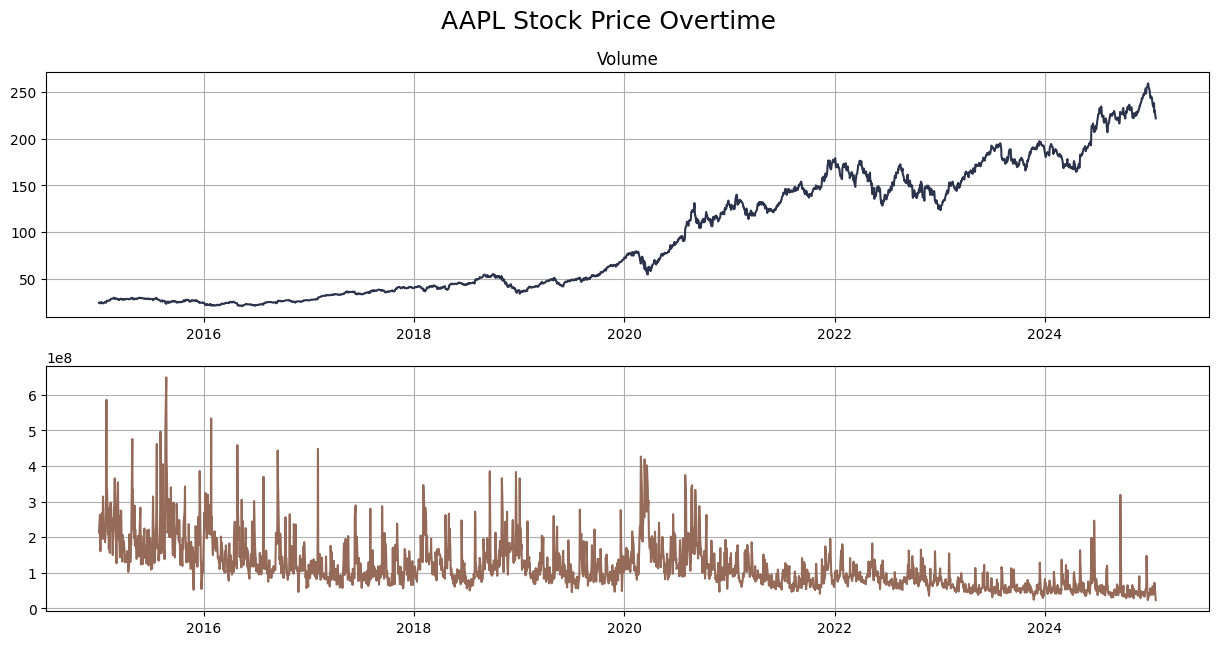

In [17]:
lineplot_stock(aapl_data, "AAPL")

<Axes: xlabel='Date', ylabel='High'>

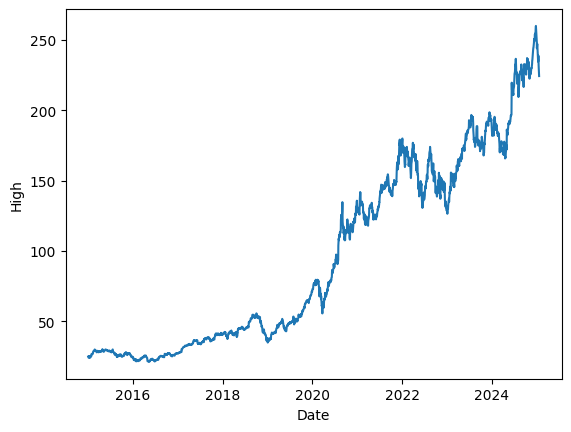

In [18]:
# experiment
sns.lineplot(x=aapl_data.index, y=aapl_data['High'])

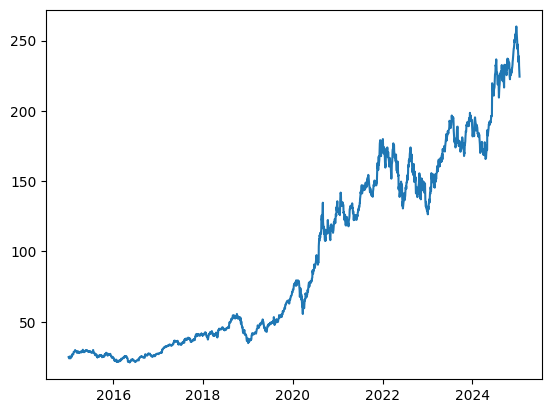

In [19]:
# experiment
plt.plot(aapl_data.index, aapl_data['High'])

## Bar chart

```
Apa itu Bar Chart? 🤔
```

Sesuai dengan namanya, bar merujuk pada bentuk segiempat yang mana kegunaan utamanya adalah untuk komparasi data kategori. Yang akan dibahas pada workshop kali ini akan ada 4 macam :
1. Simple Bar
2. Stacked Bar
3. Normalized Stacked Bar
4. Multiple Bar

### 1. Simple Bar

```
Contoh Penggunaan Simple Bar📈
```

Text(0.5, 1.0, 'Class Distribution')

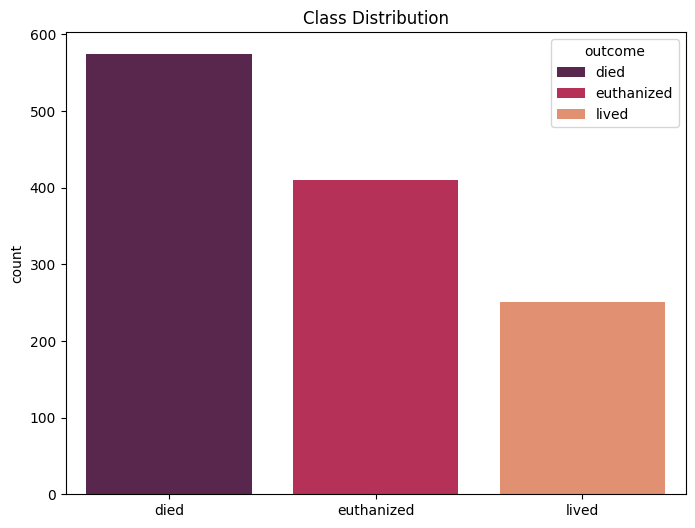

In [20]:
x = horse_health_data['outcome'].unique()
y = horse_health_data['outcome'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=x, y=y, palette="rocket", hue=x, legend=True)
plt.legend(title="outcome")
plt.title("Class Distribution")

In [21]:
# experiment


### 2. Stacked Bar

```
Contoh Pengunaan Stacked Bar 📈
```

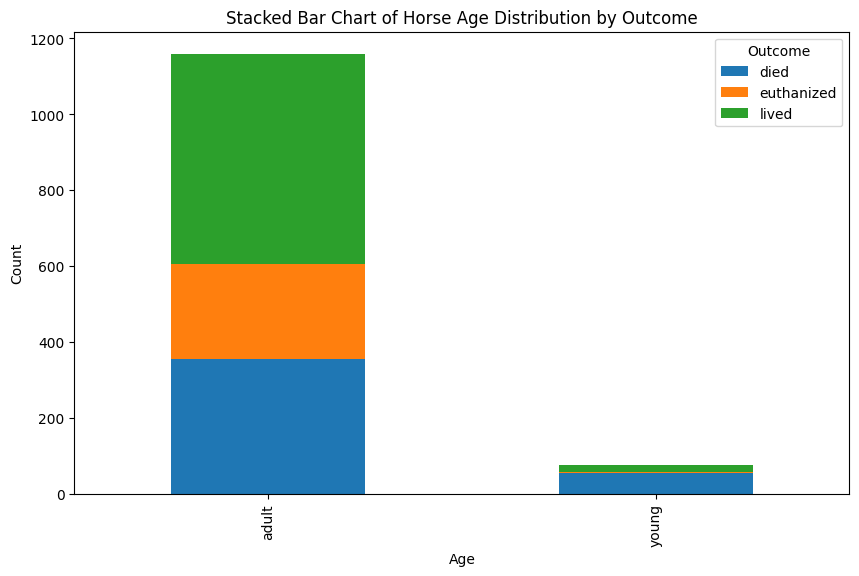

In [22]:
# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
age_count.plot(kind='bar', stacked=True, ax=ax)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Stacked Bar Chart of Horse Age Distribution by Outcome")
plt.legend(title="Outcome")
plt.show()

In [23]:
age_count['lived']

,lived
age,
adult,556
young,18


In [24]:
# experiment


### 3. Normalized Stacked Bar

```
Contoh Penggunaan Normalized Stacked Bar Chart 📈
```

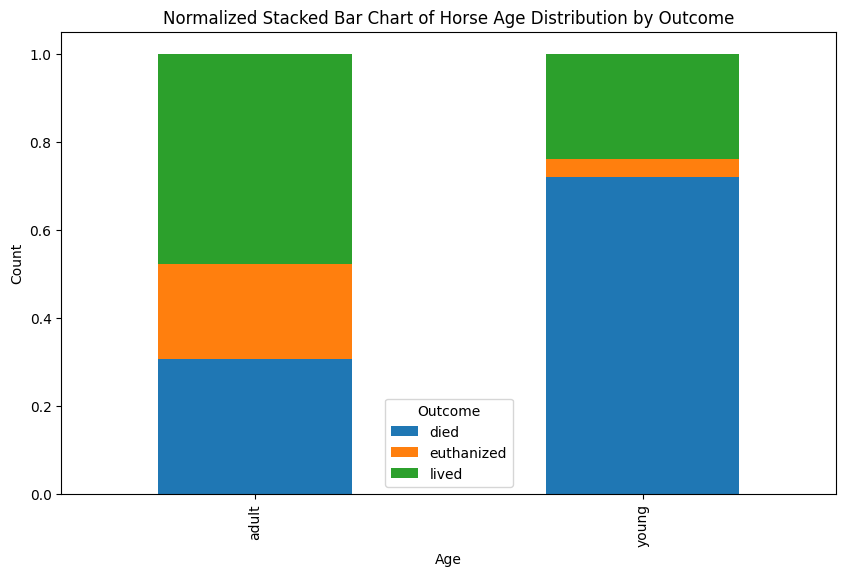

In [25]:
age_count_normalized = age_count.div(age_count.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 6))
age_count_normalized.plot(kind='bar', stacked=True, ax=ax, )

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Normalized Stacked Bar Chart of Horse Age Distribution by Outcome")
plt.legend(title="Outcome")
plt.show()

In [26]:
# experiment


### 4. Clustered (Multiple) Bar

```
Contoh Multiple (Clustered) Bar Chart 📈
```

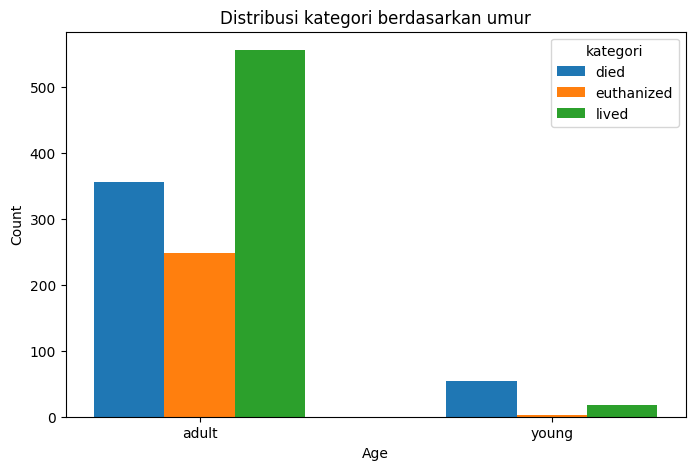

In [27]:
X_axis = np.arange(len(age_count))
plt.figure(figsize=(8, 5))
plt.bar(X_axis - 0.2, age_count['died'], 0.2, label="died")
plt.bar(X_axis, age_count['euthanized'], 0.2, label="euthanized")
plt.bar(X_axis + 0.2, age_count['lived'], 0.2, label="lived")

plt.xticks(X_axis, horse_health_data['age'].unique())
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribusi kategori berdasarkan umur")
plt.legend(title="kategori")

<Axes: xlabel='age', ylabel='count'>

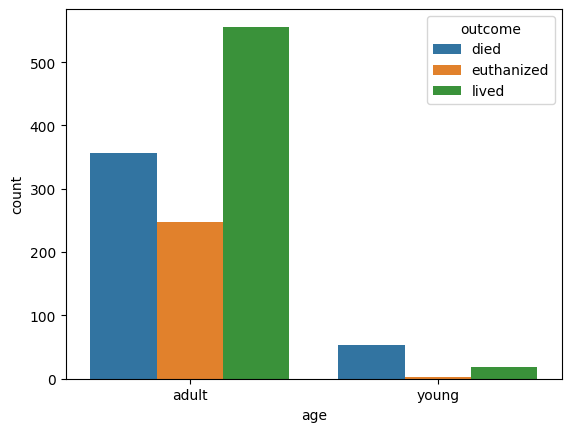

In [28]:
# experiment
sns.countplot(data=horse_health_data, x="age", hue="outcome")

## Histogram

```
Apa itu histogram? 🤔
```

Histogram berfugnsi untuk visualisasi frekuensi pada rentang tertentu atau secara umum biasa digunakan untuk visualisasi distribusi data. Distribusi sendiri secara umum ada 3 yang perlu diketahui :

```
Gejala Umum pada Distribusi 📈
```

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250610182733685996/part_of_speech_pos_tagging_with_hidden_markov_model.webp" alt="Jenis Distribusi">

1. Positive Skewness (Right Skew)

```
Mean > Median > Mode
```

2. Negative Skewness (Left Skew)

Relationship:

```
Mean < Median < Mode
```

3. Zero Skewness (Symmetrical Distribution)
```
Mean = Median = Mode
```

```
Contoh Penggunaan Histogram 📈
```

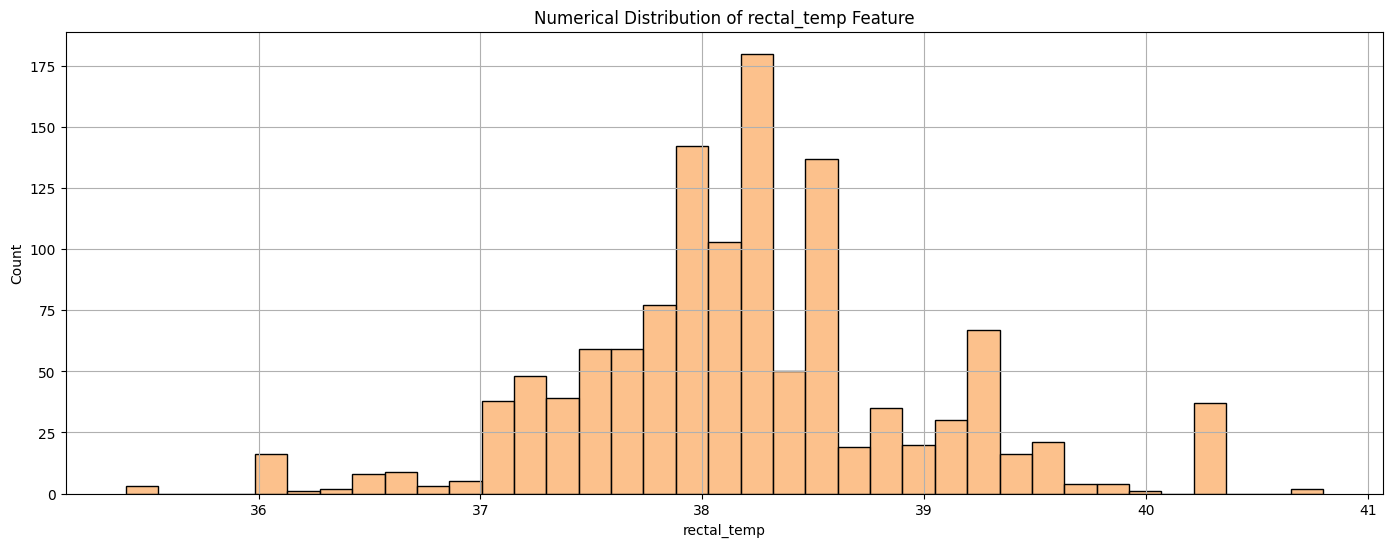

In [29]:
# Distribusi histogram `rectal_temp`
plt.figure(figsize=(17,6))
sns.histplot(horse_health_data['rectal_temp'], color="#fcac66")
plt.title('Numerical Distribution of rectal_temp Feature')
plt.grid()

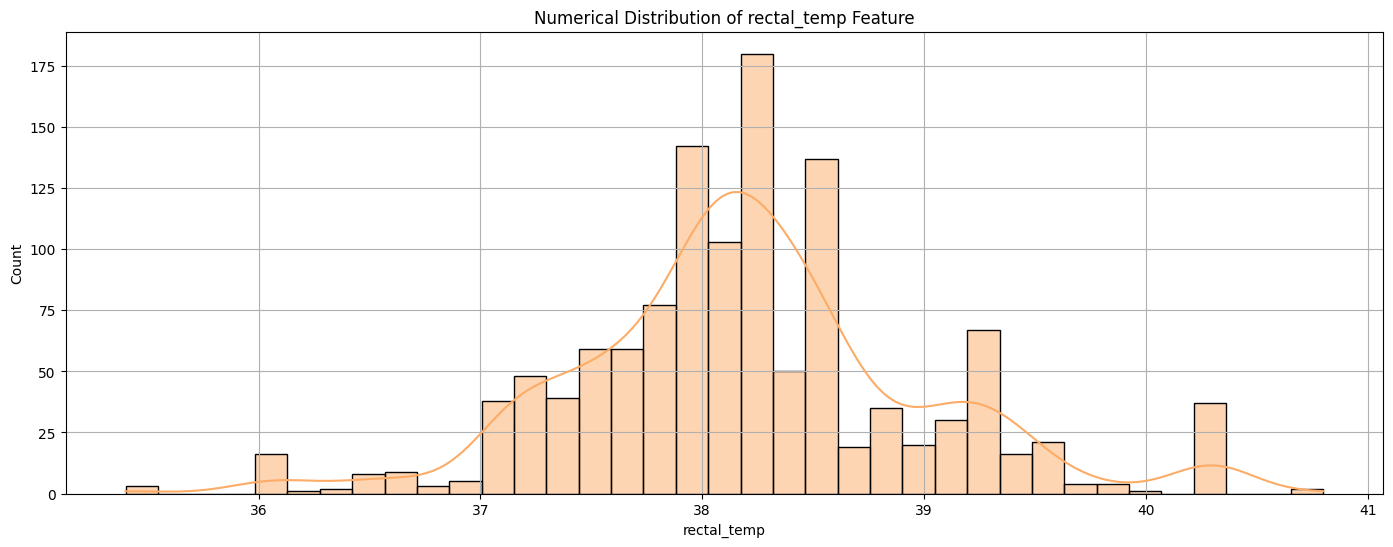

In [30]:
# Distribusi histogram `rectal_temp` dengan KDE (Kernel Density Estimation)
plt.figure(figsize=(17,6))
sns.histplot(horse_health_data['rectal_temp'], kde=True, color="#fcac66")
plt.title('Numerical Distribution of rectal_temp Feature')
plt.grid()

In [31]:
# experiment


### Uji Normalitas & Skewness

```
Buat apa uji normalitas??
```

Tujuan dari uji normalitas untuk melihat dari karakteristik data, apakah menunjukan bahwa adanya skewness (kemiringan) dari distribusi data.

Cara paling sederhana untuk melihat kemiringan adalah dengan langsung mendapatkan `.skew()` dari data

```
skew = 0 → simetris
```
```
skew > 0 → right skew
```
```
skew < 0 → left skew
```

In [32]:
print(f"Skewness: {horse_health_data['rectal_temp'].skew()}")

Skewness: 0.20940420335108284


In [33]:
aapl_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2528 entries, 2015-01-02 to 2025-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2528 non-null   float64
 1   High    2528 non-null   float64
 2   Low     2528 non-null   float64
 3   Open    2528 non-null   float64
 4   Volume  2528 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 118.5 KB


Skewness: 1.9912288703917027


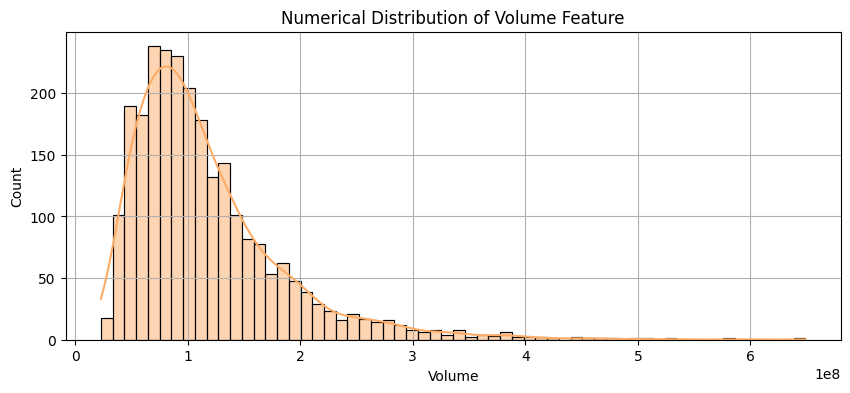

In [34]:
# Contoh lainnya untuk skewness dan distribusi data AAPL (dalam histogram)

print(f"Skewness: {aapl_data['Volume'].skew()}")

plt.figure(figsize=(10,4))
sns.histplot(aapl_data['Volume'], kde=True, color="#fcac66")
plt.title('Numerical Distribution of Volume Feature')
plt.grid()

Skewness: -0.07787482039630901


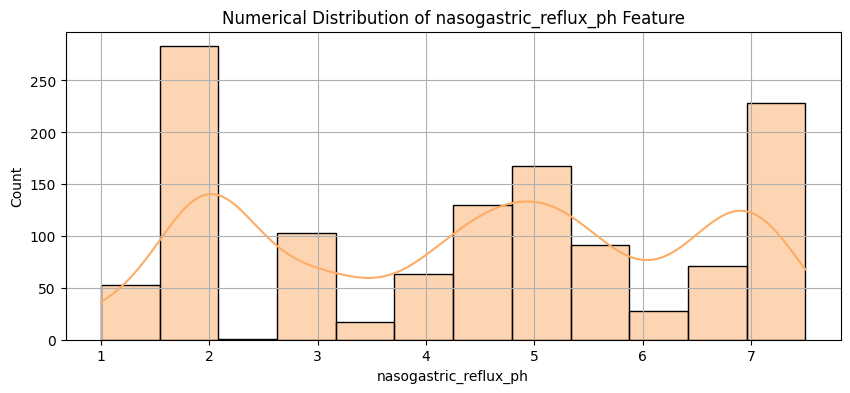

In [35]:
print(f"Skewness: {horse_health_data['nasogastric_reflux_ph'].skew()}")

plt.figure(figsize=(10,4))
sns.histplot(horse_health_data['nasogastric_reflux_ph'], kde=True, color="#fcac66")
plt.title('Numerical Distribution of nasogastric_reflux_ph Feature')
plt.grid()

### Q-Q Plot

Salah satu pengujian normalitas menggunakan visual adalah `Q-Q Plot` atau `Quantile-Quantile Plot`

```
Apa itu QQ Plot?
```

QQ Plot sendiri merupakan metode visual untuk membandingkan dua probabilitas distribusi dengan memetakan quartile (kuantil) satu sama lain. QQ Plot dapat digunakan untuk membandingkan distribusi kuantil data dengan kuantil distribusi normal

Lihat lebih lanjut mengenai QQPlot: https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot

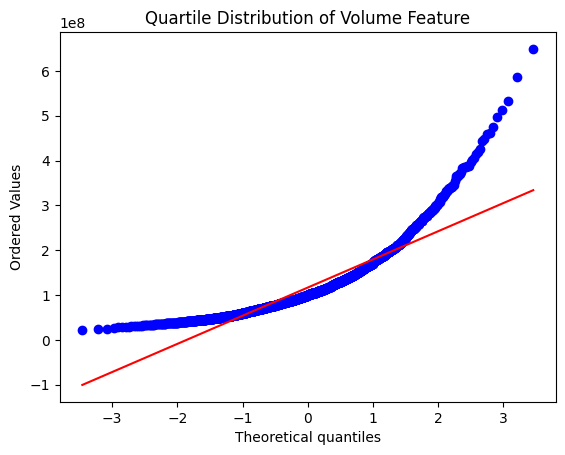

In [36]:
# Melihat normalitas data dengan kuartil data Volume
stats.probplot(aapl_data['Volume'], dist="norm", plot=plt)
plt.title('Quartile Distribution of Volume Feature')
plt.show()

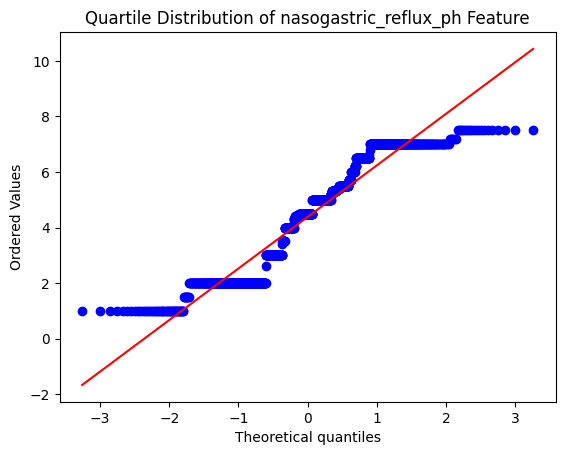

In [37]:
# Melihat normalitas data dengan kuartil data nasogastric_reflux_ph
stats.probplot(horse_health_data['nasogastric_reflux_ph'], dist="norm", plot=plt)
plt.title('Quartile Distribution of nasogastric_reflux_ph Feature')
plt.show()

### Uji Statistik (Shapiro, KSTest, dkk)


Selain itu, ada metode uji statistik yang bisa menilai apakah distribusi data normal atau tidak, misalnya seperti uji `Shapiro-Wilk`, uji `Kolmogorov-Smirnov`, dan lainnya. Kalian bisa eksplor lebih lanjut disini

- https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html#scipy.stats.shapiro
- https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

## Scatter plot

```
Apa itu histogram? 🤔
```

Salah satu visualisasi yang menunjukkan hubungan antar 2 variabel/fitur/kolom. Tiap data pada scatter plot akan direpresentasikan pada bentuk dot atau titik

```
Contoh Penggunaan 📈
```

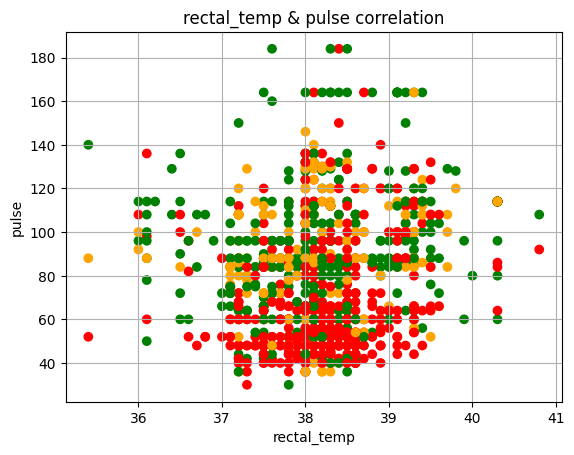

In [38]:
colors = {
    "died": "green",
    "euthanized": "orange",
    "lived": "red"
}
scatter_colors = [colors[k] for k in horse_health_data['outcome']]

plt.scatter(horse_health_data["rectal_temp"], horse_health_data["pulse"], c=scatter_colors)
plt.title("rectal_temp & pulse correlation")
plt.xlabel("rectal_temp")
plt.ylabel("pulse")
plt.grid()

In [39]:
# experiment


### Bonus: Pairplot

Pairplot merupakan fungsi dalam library seaborn yang secara otomatis memetakan relasi pairwise dengan visualisasi scatter plot untuk relasi antar variabel.

`!!!TAPI!!!` Metode ini sangat berat karena mencoba seluruh possible relationship (selama numerik) dan tidak cocok untuk data besar.

In [40]:
# jangan di running (lama soalnya)
# sns.pairplot(horse_health_data, hue="outcome")

Contoh tampilan pairplot sederhana

<img src="https://seaborn.pydata.org/_images/pairplot_1_0.png">

## Pie Chart

```
Apa itu Pie Chart? 🤔
```

Satu visualisasi yang bertujuan untuk mencari insight terkait proporsi (% or °)

```
Contoh Pengunaan 📈
```

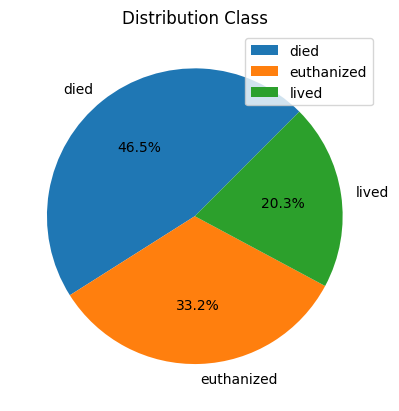

In [41]:
label = horse_health_data["outcome"].unique()
size = horse_health_data["outcome"].value_counts()

plt.pie(size, labels=label, autopct="%1.1f%%", startangle=45)
plt.title("Distribution Class")
plt.legend()
%matplotlib inline

### Piechart (Doughnut)

Salah satu cara untuk kustomisasi pie chart adalah membuat pie chart sebagai donut (jadi ada bolong tengahnya). Ini bentuk variasi dari pie chart

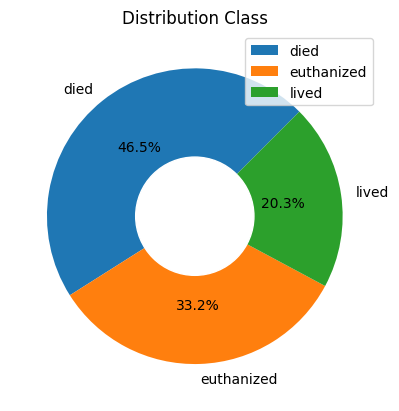

In [42]:
plt.pie(size, labels=label, autopct="%1.1f%%", startangle=45)

# Membuat circle di tengah, layaknya donut
my_circle = plt.Circle( (0,0), 0.4, color='white')
p = plt.gcf()
p.gca().add_artist(my_circle)

plt.title("Distribution Class")
plt.legend()
%matplotlib inline

### Piechart (Explode)

Salah satu kustomisasi dari pie chart adalah menambahkan jarak antar tiap `pie`nya. Ini sebatas pemanis mata saja dan memberikan variasi dari pie chart

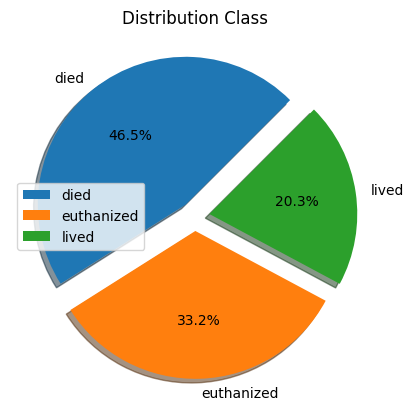

In [43]:
explode_size = [0.1] * len(label)

plt.pie(size, labels=label, autopct="%1.1f%%", explode=explode_size, shadow=True, startangle=45)
plt.title("Distribution Class")
plt.legend()
%matplotlib inline

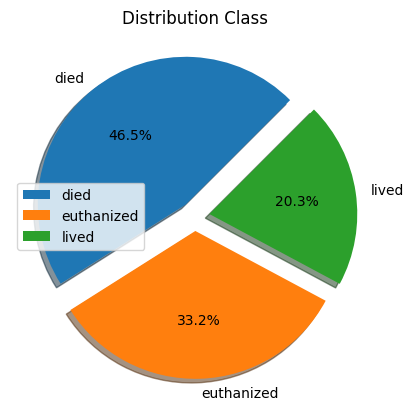

In [44]:
explode_size = [0.1] * len(label)

plt.pie(size, labels=label, autopct="%1.1f%%", explode=explode_size, shadow=True, startangle=45)
plt.title("Distribution Class")
plt.legend()
%matplotlib inline

In [45]:
# experiment


### VERY BIG CAVEAT with pie chart

Piechart ini sebenernya salah satu jenis chart yang paling tidak disukai orang. Alasannya adalah umumnya manusia (kita) itu sulit dalam membaca/mengkirakan angle atau sudut.

Berikut contoh membandingkan pie chart 5 nilai unik dengan bar chart 5 nilai unik

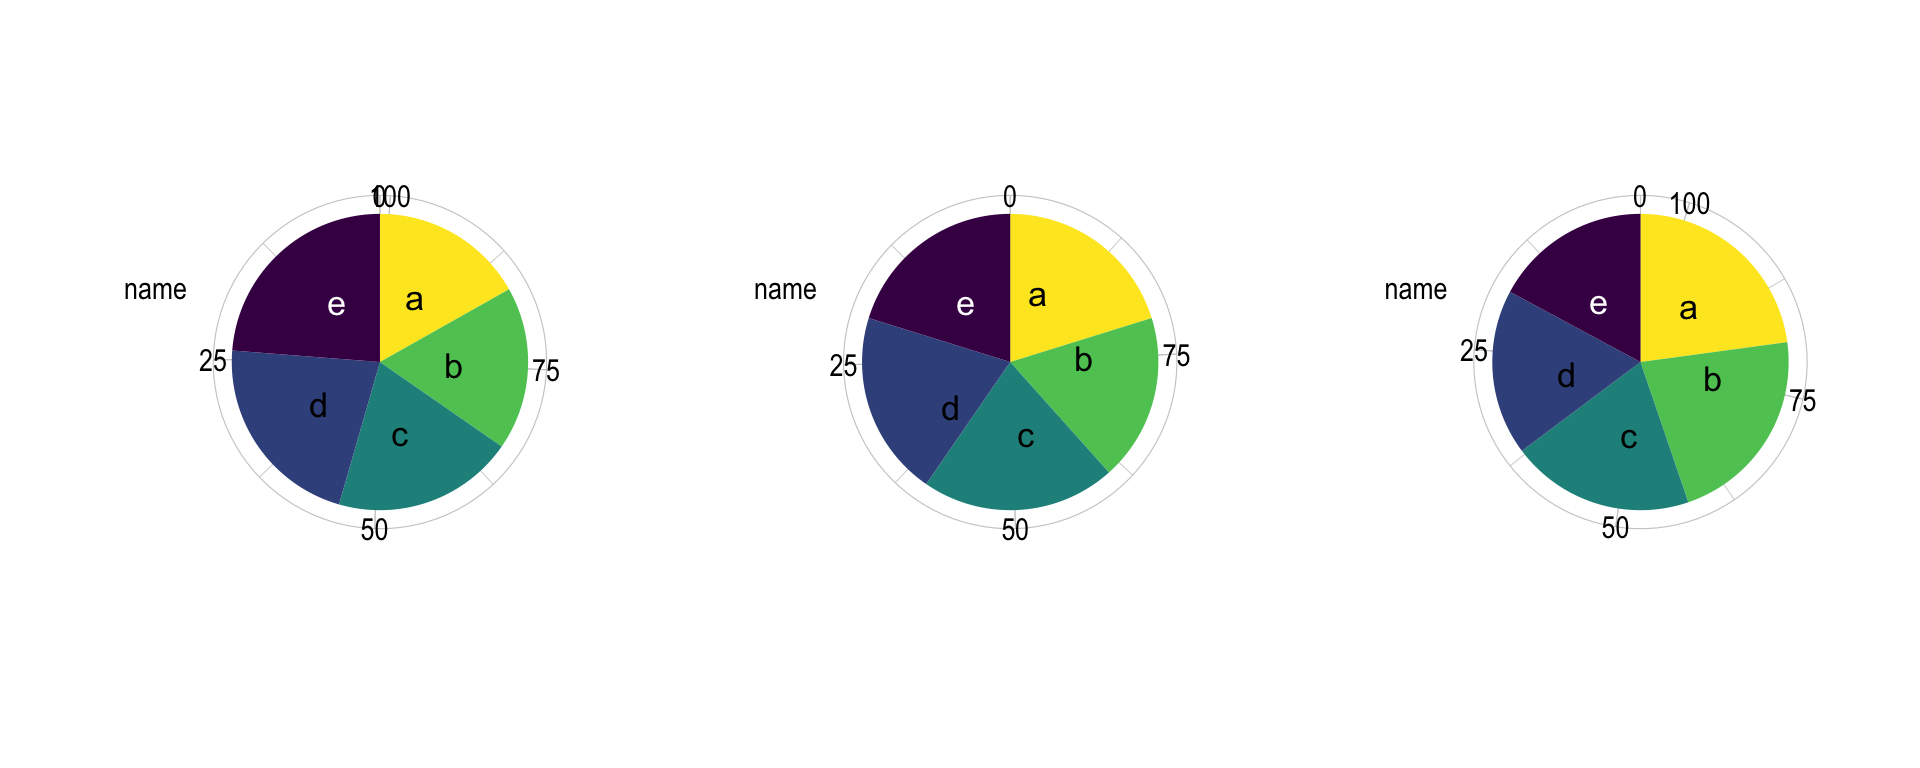

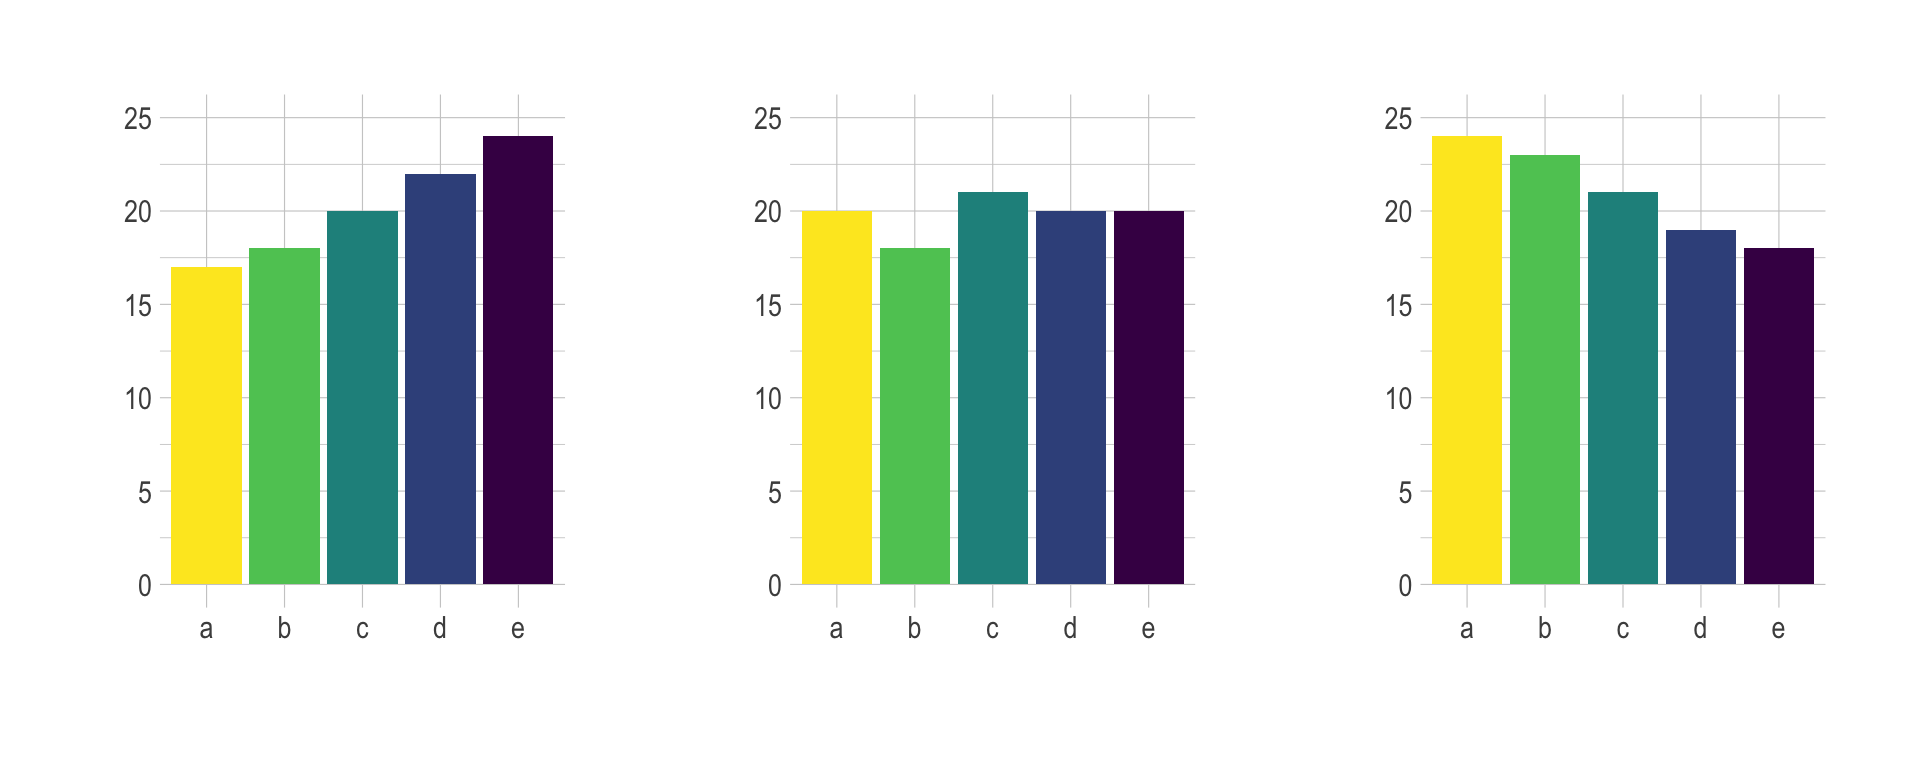

Jika tidak diberikan label spesifik (total nilai masing-masing item) maka akan sulit membedakan jumlah item unik yang paling banyak atau sedikit.

Lord Grace reasoning untuk tidak menggunakan piechart:
- Item unik lebih dari 3 (atau 2 item)
- Jika tidak ada legend atau label (bedanya apa wak)
- Tidak spesifik angka dari total item (atau persentase item)


Daripada menggunakan piechart (terutama jika memiliki banyak item unik), gunakan seperti `Bar Chart`, `Lollipop Chart`, atau `Treemap`.

Referensi: https://www.data-to-viz.com/caveat/pie.html

## Heatmap

```
Apa itu Heatmap? 🤔
```

Salah satu visualisasi yang bertujuan untuk menggali insight korelasi dari dua variabel/fitur. Cara kerjanya adalah mengukur *heat* dari hasil korelasi yang sudah didapat

```
Contoh Pengunaan 📈
```

Text(0.5, 1.05, 'Feature Correlation')

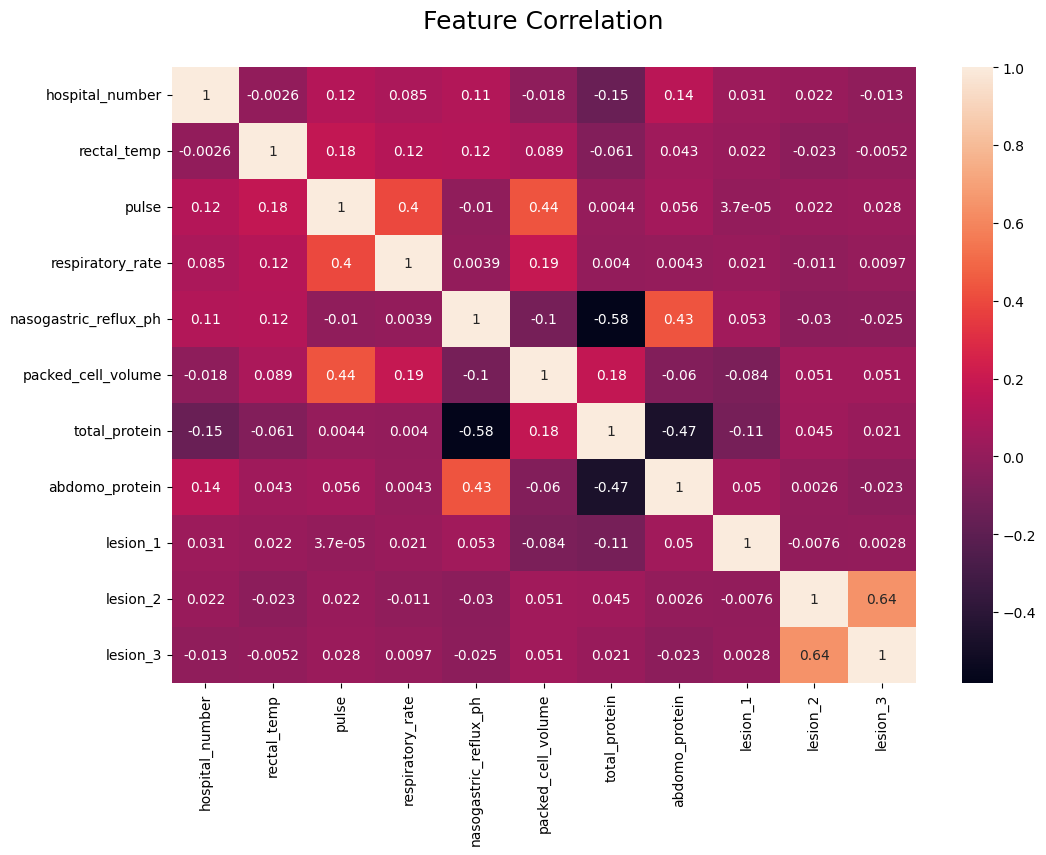

In [46]:
plt.figure(figsize=(12,8))
num_feature = horse_health_data.select_dtypes(include=['number'])
num_feature.drop(columns='id', inplace=True)
sns.heatmap(num_feature.corr(), annot=True, cmap="rocket")
plt.title('Feature Correlation', fontsize=18, y=1.05)

Sauce : https://www.researchgate.net/figure/The-scale-of-Pearsons-Correlation-Coefficient_tbl1_345693737

### Korelasi Chi Square

Perlu diingat, bahwa `visualisasi` dan analisis `korelasi pairwise` di atas hanya untuk fitur numerik. Tidak berlaku untuk data kategori maupun nominal karena relasi dan analisis korelasinya berbeda

In [47]:
from scipy.stats import chi2_contingency

Berikut merupakan contoh metode untuk menganalisis asosiasi data kategorikal, yaitu Chi Square Assosiation.

Bisa cek link dibawah ini jika ingin eksplorasi Chi Square lebih lanjut:
- https://www.geeksforgeeks.org/maths/chi-square-test/
- https://www.geeksforgeeks.org/data-science/chi-square-test-in-data-science-and-data-analytics/

In [48]:
contingency_table = pd.crosstab(horse_health_data['age'], horse_health_data['outcome'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square: {chi2}")
print(f"P-Value: {p}")

outcome  died  euthanized  lived
age                             
adult     356         248    556
young      54           3     18
Chi-Square: 55.36138557149511
P-Value: 9.515417931070396e-13


In [49]:
# experiment


## Treemap

```
Apa itu Treemap? 🤔
```

Treemap adalah representasi data hierarikal dengan kumpulan persegi panjang. Setiap grup akan direpresentasikan dengan persegi panjang dan ukurannya berdasarkan nilainya.

In [50]:
!pip install squarify # install library treemap

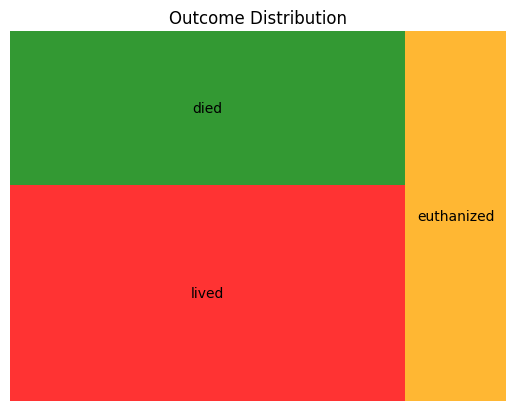

In [51]:
import squarify

counts = horse_health_data['outcome'].value_counts()

squarify.plot(
    sizes=counts.values,
    label=counts.index,
    color=[colors[i] for i in counts.index],
    alpha=0.8
)

plt.title("Outcome Distribution")
plt.axis("off")
plt.show()

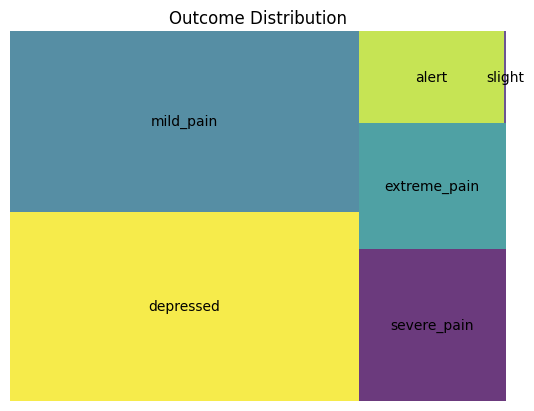

In [52]:
counts = horse_health_data['pain'].value_counts()

squarify.plot(
    sizes=counts.values,
    label=counts.index,
    alpha=0.8
)

plt.title("Outcome Distribution")
plt.axis("off")
plt.show()

## Boxplot

```
Apa itu Boxplot? 🤔
```

Boxplot (box-and-whisker plot) adalah jenis diagram yang digunakan untuk menampilkan distribusi data berdasarkan lima nilai statistik utama:

- **Minimum** (nilai terkecil, kecuali outlier)
- **Kuartil pertama** (Q1) - 25% data terendah
- **Median** (Q2) - 50% dari data (nilai tengah)
- **Kuartil** ketiga (Q3) - 75% data terendah
- **Maksimum** (nilai terbesar, kecuali outlier)

<img src="https://www.simplypsychology.org/boxplot.jpg?ezimgfmt=rs:555x285/rscb30/ng:webp/ngcb30" alt="boxplot structure" width=500>

```
Contoh Pengunaan 📈
```

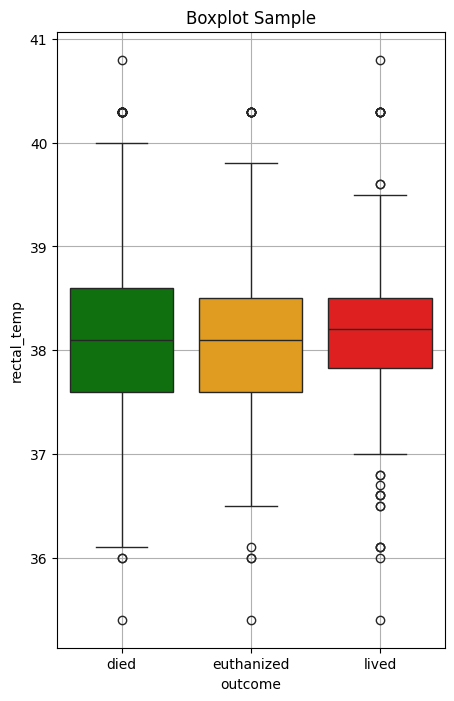

In [53]:
plt.figure(figsize=(5,8))
sns.boxplot(x=horse_health_data['outcome'], y=horse_health_data['rectal_temp'], hue=horse_health_data['outcome'], palette=colors)
plt.title("Boxplot Sample")
plt.grid()
%matplotlib inline

In [54]:
# experiment


## Pairplot

```
Apa itu Pairplot? 🤔
```

Bentuk lain untuk visualisasi data yang menampilkan hubungan pairwise (berpasangan) antara semua variabel numerik dalam dataset.

```
Contoh Pengunaan 📈
```

Text(0.5, 1.03, 'Pairplot of some numerical feature')

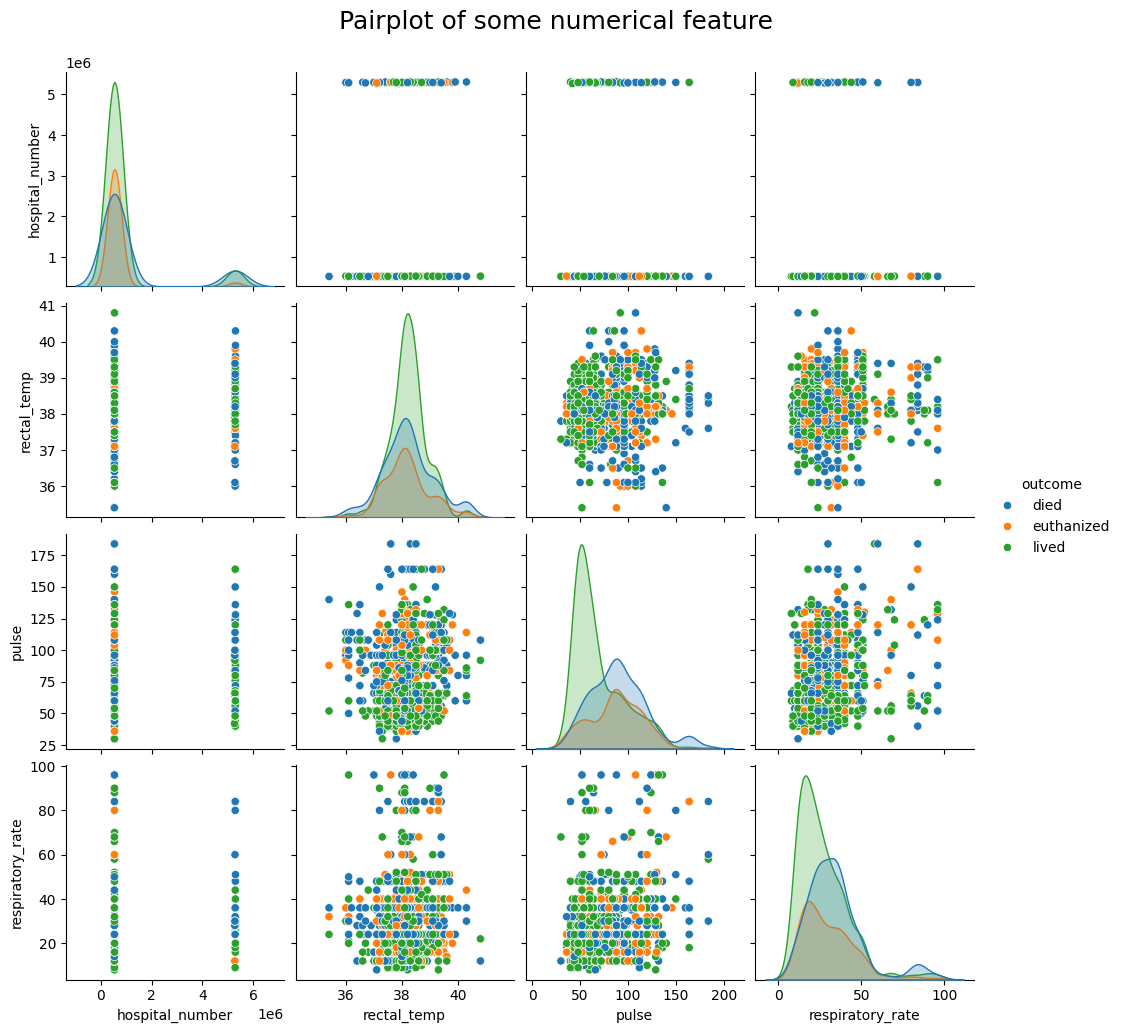

In [55]:
df_num = pd.concat([num_feature.iloc[:, :4], horse_health_data['outcome']], axis=1)
axes = sns.pairplot(df_num, hue="outcome")
plt.suptitle("Pairplot of some numerical feature", fontsize=18, y=1.03)

## Word Cloud

```
Apa itu Word Cloud? 🤔
```

Word cloud merupakan representasi visual dari teks data, dimana terdiri dari kata tunggal dan ukuran font/warna dipengaruhi dari seberapa penting (atau seberapa banyak kata tunggal tersebut ada dalam teks).

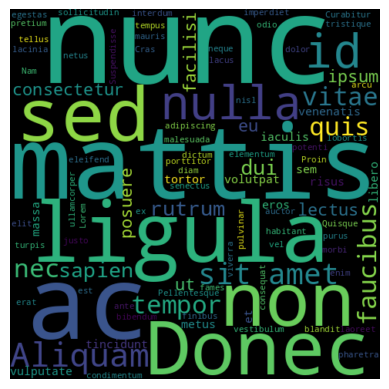

In [56]:
# Create a list of word
text="""
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Donec non lacinia nunc, sed tempor tellus. Donec faucibus ante vitae neque bibendum mattis. Duis ut tempor nulla. Cras ac erat a lectus posuere mattis. Nulla facilisi. Nam id nunc eu est vulputate dictum sit amet vestibulum ex. Aliquam mattis justo quis condimentum lobortis. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Curabitur auctor non massa a sollicitudin. Aliquam vulputate porttitor blandit. Sed id lectus a risus viverra faucibus id nec sapien. Nunc diam sapien, tincidunt sed libero ac, interdum elementum sem. Aliquam quis imperdiet tortor, sit amet pharetra risus.
Aliquam iaculis enim massa, eu venenatis dui posuere nec. Donec sem ligula, eleifend vel eros ullamcorper, volutpat rutrum metus. Donec vitae volutpat sapien, quis pulvinar dui. Suspendisse potenti. Nulla tempor ligula ligula, ac rutrum libero faucibus sit amet. Nunc pretium, nisl rutrum mattis mattis, ligula mauris tincidunt arcu, vitae finibus nulla eros non odio. Quisque ac ipsum sed purus consequat venenatis id nec metus. Proin laoreet nunc tortor, non tempus lacus facilisis at. Ut consectetur iaculis ligula.
"""

# Create the wordcloud object
wordcloud = WordCloud(width=480, height=480, margin=0).generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

Kelemahan terbesar dari world cloud tentunya karena representasi visual, kita tidak bisa mendapat seberapa penting/banyak kata tunggal tersebut dari keseluruhan dokumen/teks. Usahakan tetap gunakan `bar chart` atau `lollipop chart` untuk menampilkan distribusi total kata tunggal.

## Geoplot (Map)

```
Apa itu Geoplot atau Map? 🤔
```

Nah, jika kamu tahu visualisasi yang menggunakan map/peta kamu bisa menggunakan geoplot. Librarynya sangat beragam seperti `geoplot` atau yang lebih kayak `Folium`. At the end of the day, untuk memetakan visualisasi yang ada unsur geografinya

In [57]:
!pip install geopandas geoplot # instalasi geoplot untuk eksperimen awal

### Data Geo (Map)

         id          GEO_ID STATE COUNTY          NAME    LSAD  CENSUSAREA  \
0     01001  0500000US01001    01    001       Autauga  County     594.436   
1     01009  0500000US01009    01    009        Blount  County     644.776   
2     01017  0500000US01017    01    017      Chambers  County     596.531   
3     01021  0500000US01021    01    021       Chilton  County     692.854   
4     01033  0500000US01033    01    033       Colbert  County     592.619   
...     ...             ...   ...    ...           ...     ...         ...   
3216  51001  0500000US51001    51    001      Accomack  County     449.496   
3217  51021  0500000US51021    51    021         Bland  County     357.725   
3218  51027  0500000US51027    51    027      Buchanan  County     502.763   
3219  51037  0500000US51037    51    037     Charlotte  County     475.271   
3220  51041  0500000US51041    51    041  Chesterfield  County     423.297   

                                               geometry  
0    

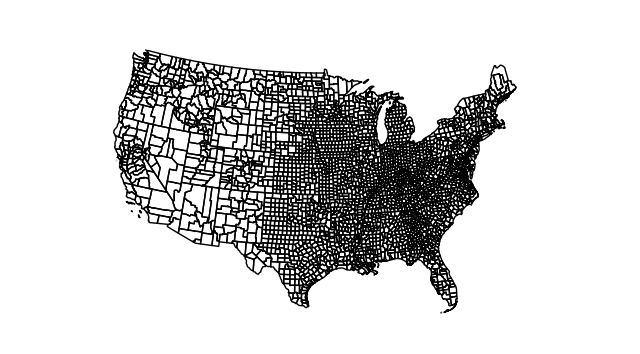

In [58]:
# Import the geopandas and geoplot libraries
import geopandas as gpd
import geoplot.crs as gcrs
import geoplot as gplt

# Load the json file with county coordinates
geoData = gpd.read_file(
    'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson'
)
print(geoData)

# Make sure the "id" column is an integer
geoData.id = geoData['id'].astype(int)

# Remove Alaska, Hawaii and Puerto Rico.
statesToRemove = ['02', '15', '72']
geoData = geoData[~geoData.STATE.isin(statesToRemove)]

# Basic plot with just county outlines
gplt.polyplot(
    geoData,
    projection=gcrs.AlbersEqualArea()
)
plt.show()

### Data Unemployment (Dengan Informasi State dan County)

     id    state          county  rate
0  1001  Alabama  Autauga County   5.1
1  1003  Alabama  Baldwin County   4.9
2  1005  Alabama  Barbour County   8.6
3  1007  Alabama     Bibb County   6.2
4  1009  Alabama   Blount County   5.1


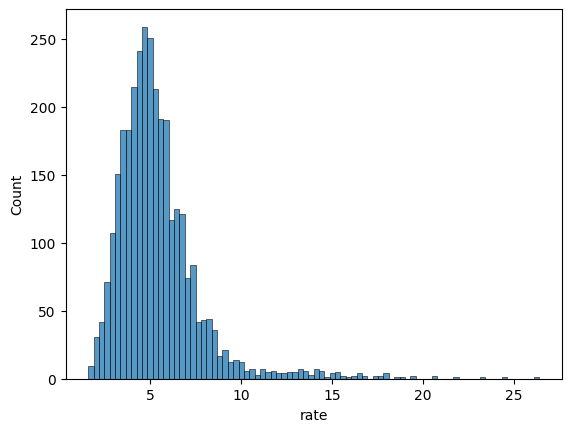

In [59]:
unemployment = pd.read_csv(
    'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/unemployment-x.csv'
)

print(unemployment.head())

sns.histplot(unemployment["rate"])
plt.show()

In [60]:
fullData = geoData.merge(
    unemployment,
    left_on=['id'],  # identifier from geodataframe
    right_on=['id']  # identifier from dataframe
)
fullData.head(3)

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry,state,county,rate
0,1001,0500000US01001,01,001,Autauga,County,594.436,"POLYGON ((-86.49677 32.34444, -86.7179 32.4028...",Alabama,Autauga County,5.1
1,1009,0500000US01009,01,009,Blount,County,644.776,"POLYGON ((-86.5778 33.76532, -86.75914 33.8406...",Alabama,Blount County,5.1
2,1017,0500000US01017,01,017,Chambers,County,596.531,"POLYGON ((-85.18413 32.87052, -85.12342 32.772...",Alabama,Chambers County,5.0


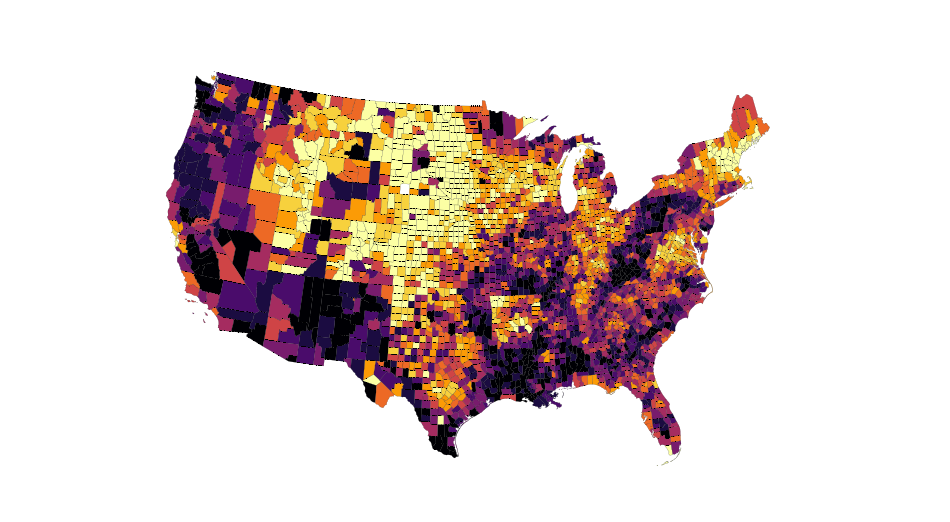

In [61]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# for color mapping with 10 different colors
import mapclassify as mc
scheme = mc.Quantiles(fullData['rate'], k=10)

# Map
gplt.choropleth(
    fullData,
    projection=gcrs.AlbersEqualArea(),
    hue="rate",
    scheme=scheme, cmap='inferno_r',
    linewidth=.1,
    edgecolor='black',
    figsize=(12, 8)
)

plt.show()

Contoh pemetaan jauh sebatas warna sebagai intensitas jumlah item, bisa menggunakan bubble map, connection map, dan sebagainya. Kalian bisa eksplor sendiri sesuai kebutuhan kalian.

Referensi:

https://python-graph-gallery.com/map/

# Preprocessing

Salah satu proses penting di data science, tujuannya adalah agar data kita ada pada kondisi sebaik mungkin untuk dilakukan training. Harapannya tentu adalah inferensi atau jawaban yang baik dari analisis data yang kita punya. Sebagai contoh:

## Missing Values Handling

<img src="https://www.researchgate.net/publication/348067403/figure/fig1/AS:1023820194410509@1621109164997/Types-of-missing-data-and-its-description.jpg">

### Visualisasi Missing Values

In [62]:
!pip install missingno

<Axes: >

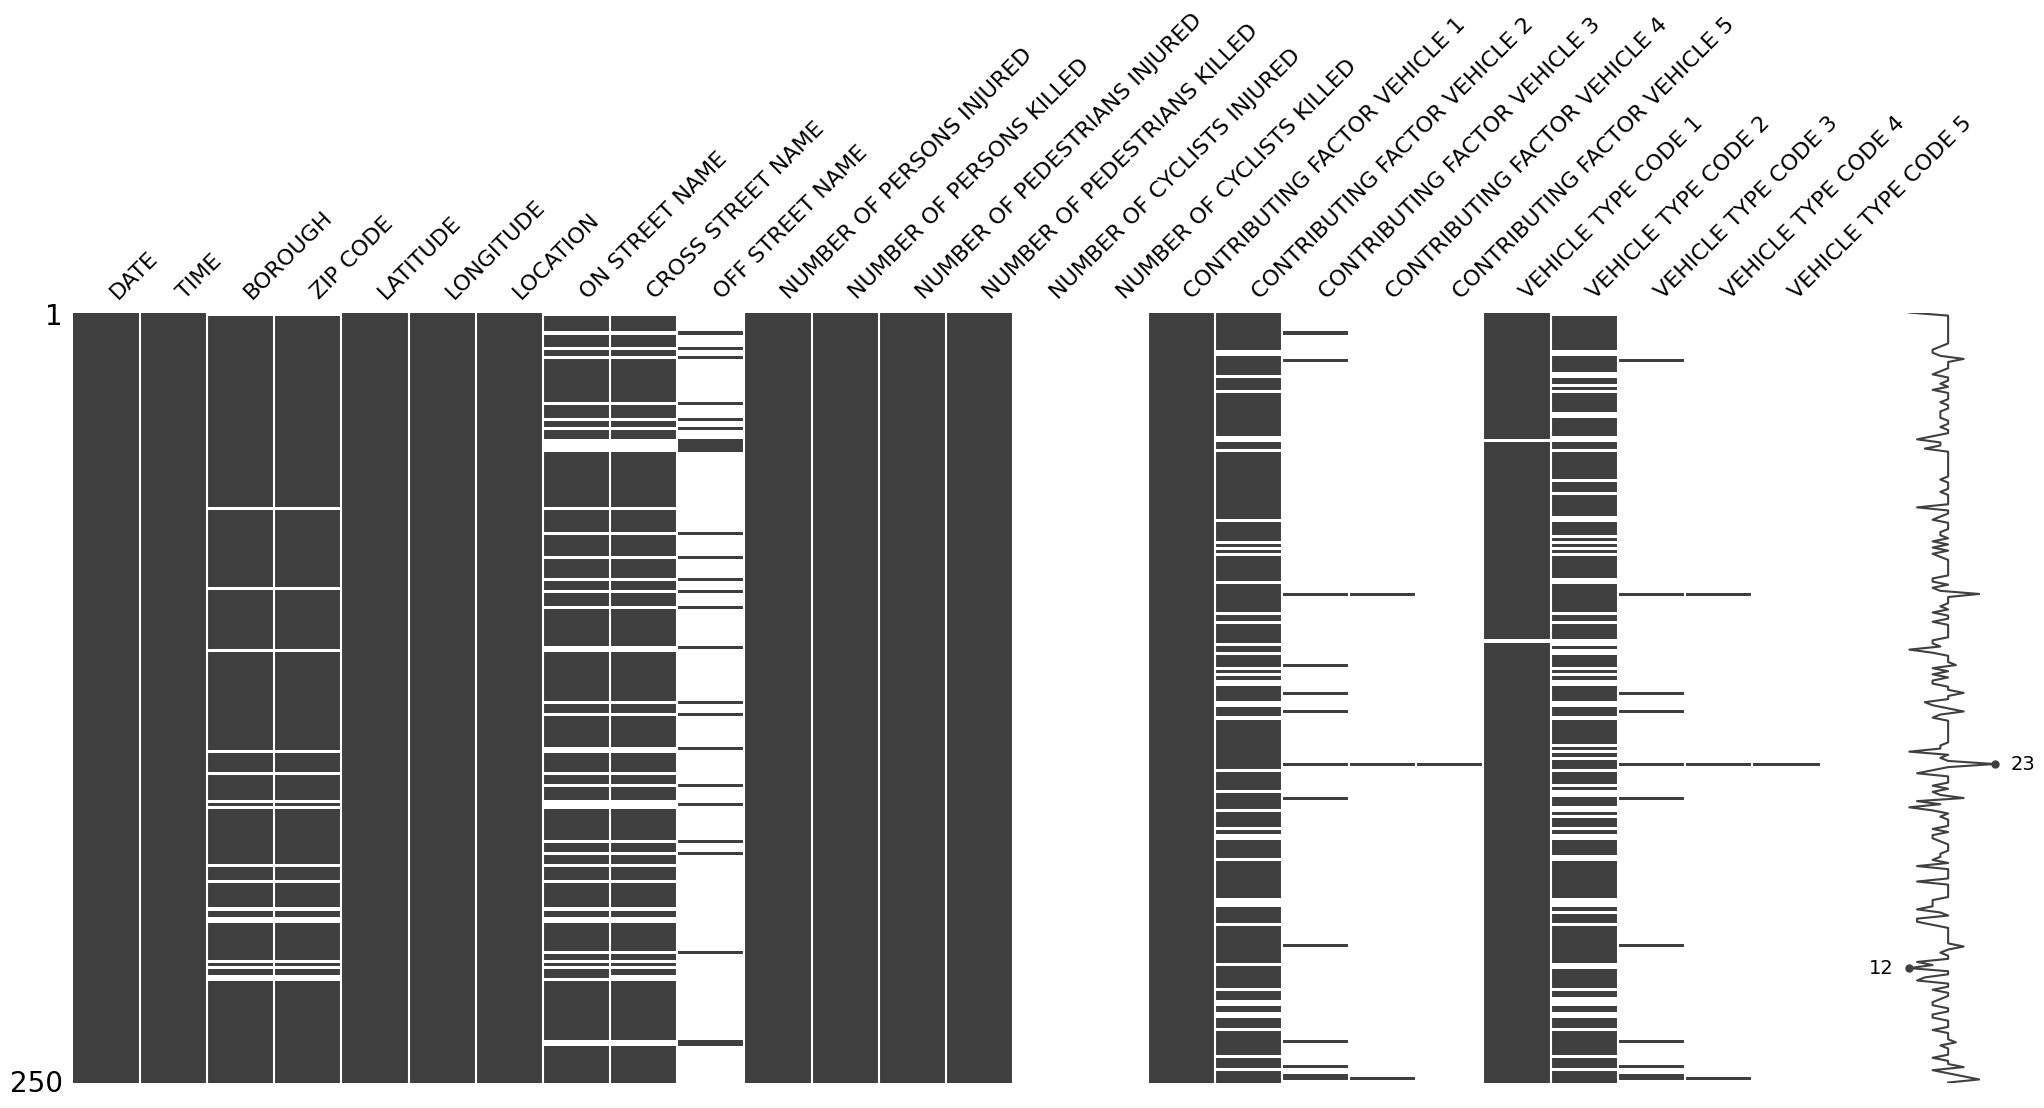

In [63]:
import missingno as msno

import pandas as pd
collisions = pd.read_csv(
    "https://raw.githubusercontent.com/ResidentMario/missingno-data/master/nyc_collision_factors.csv"
)

%matplotlib inline
msno.matrix(collisions.sample(250))

<Axes: >

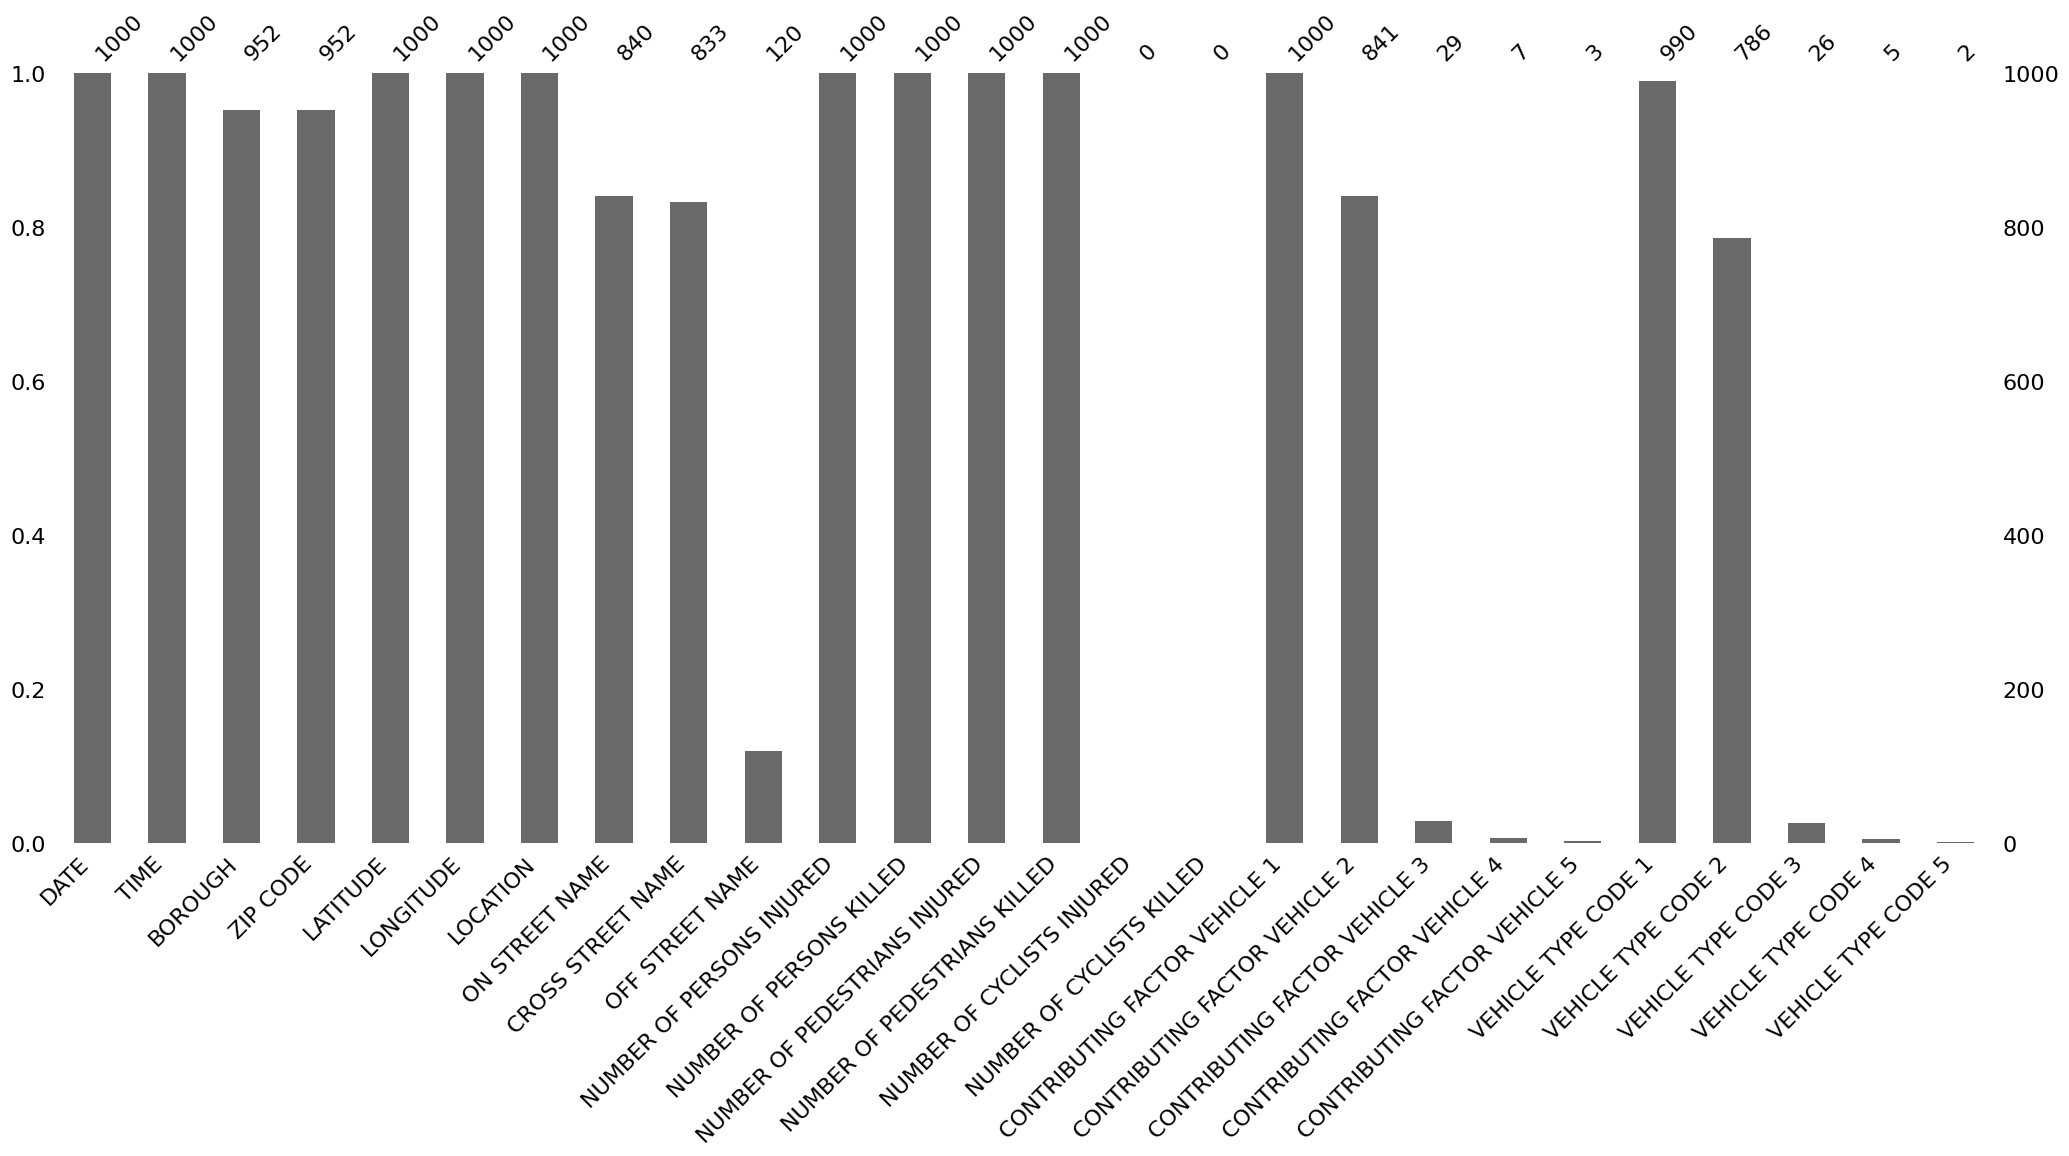

In [64]:
msno.bar(collisions.sample(1000))

<Axes: >

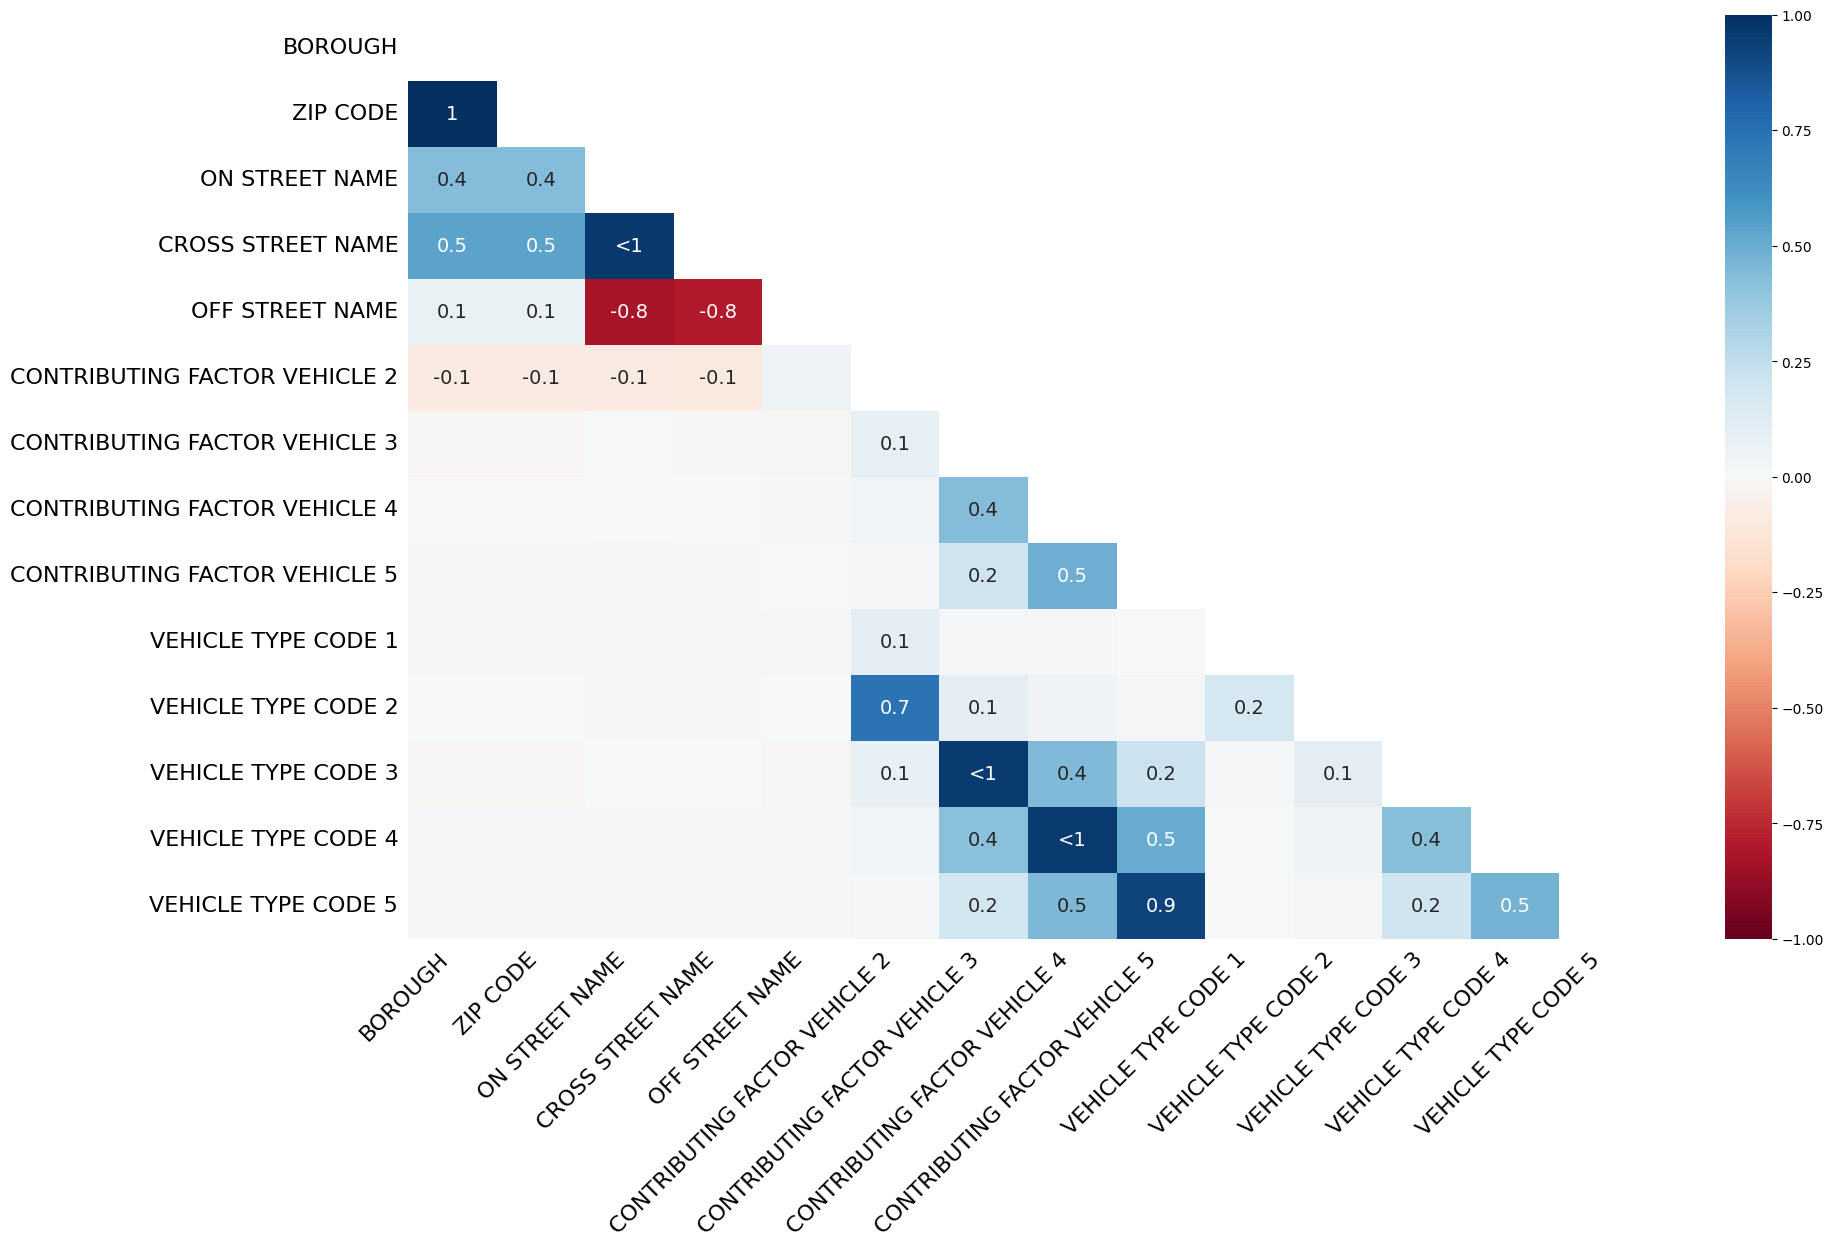

In [65]:
msno.heatmap(collisions)

<Axes: >

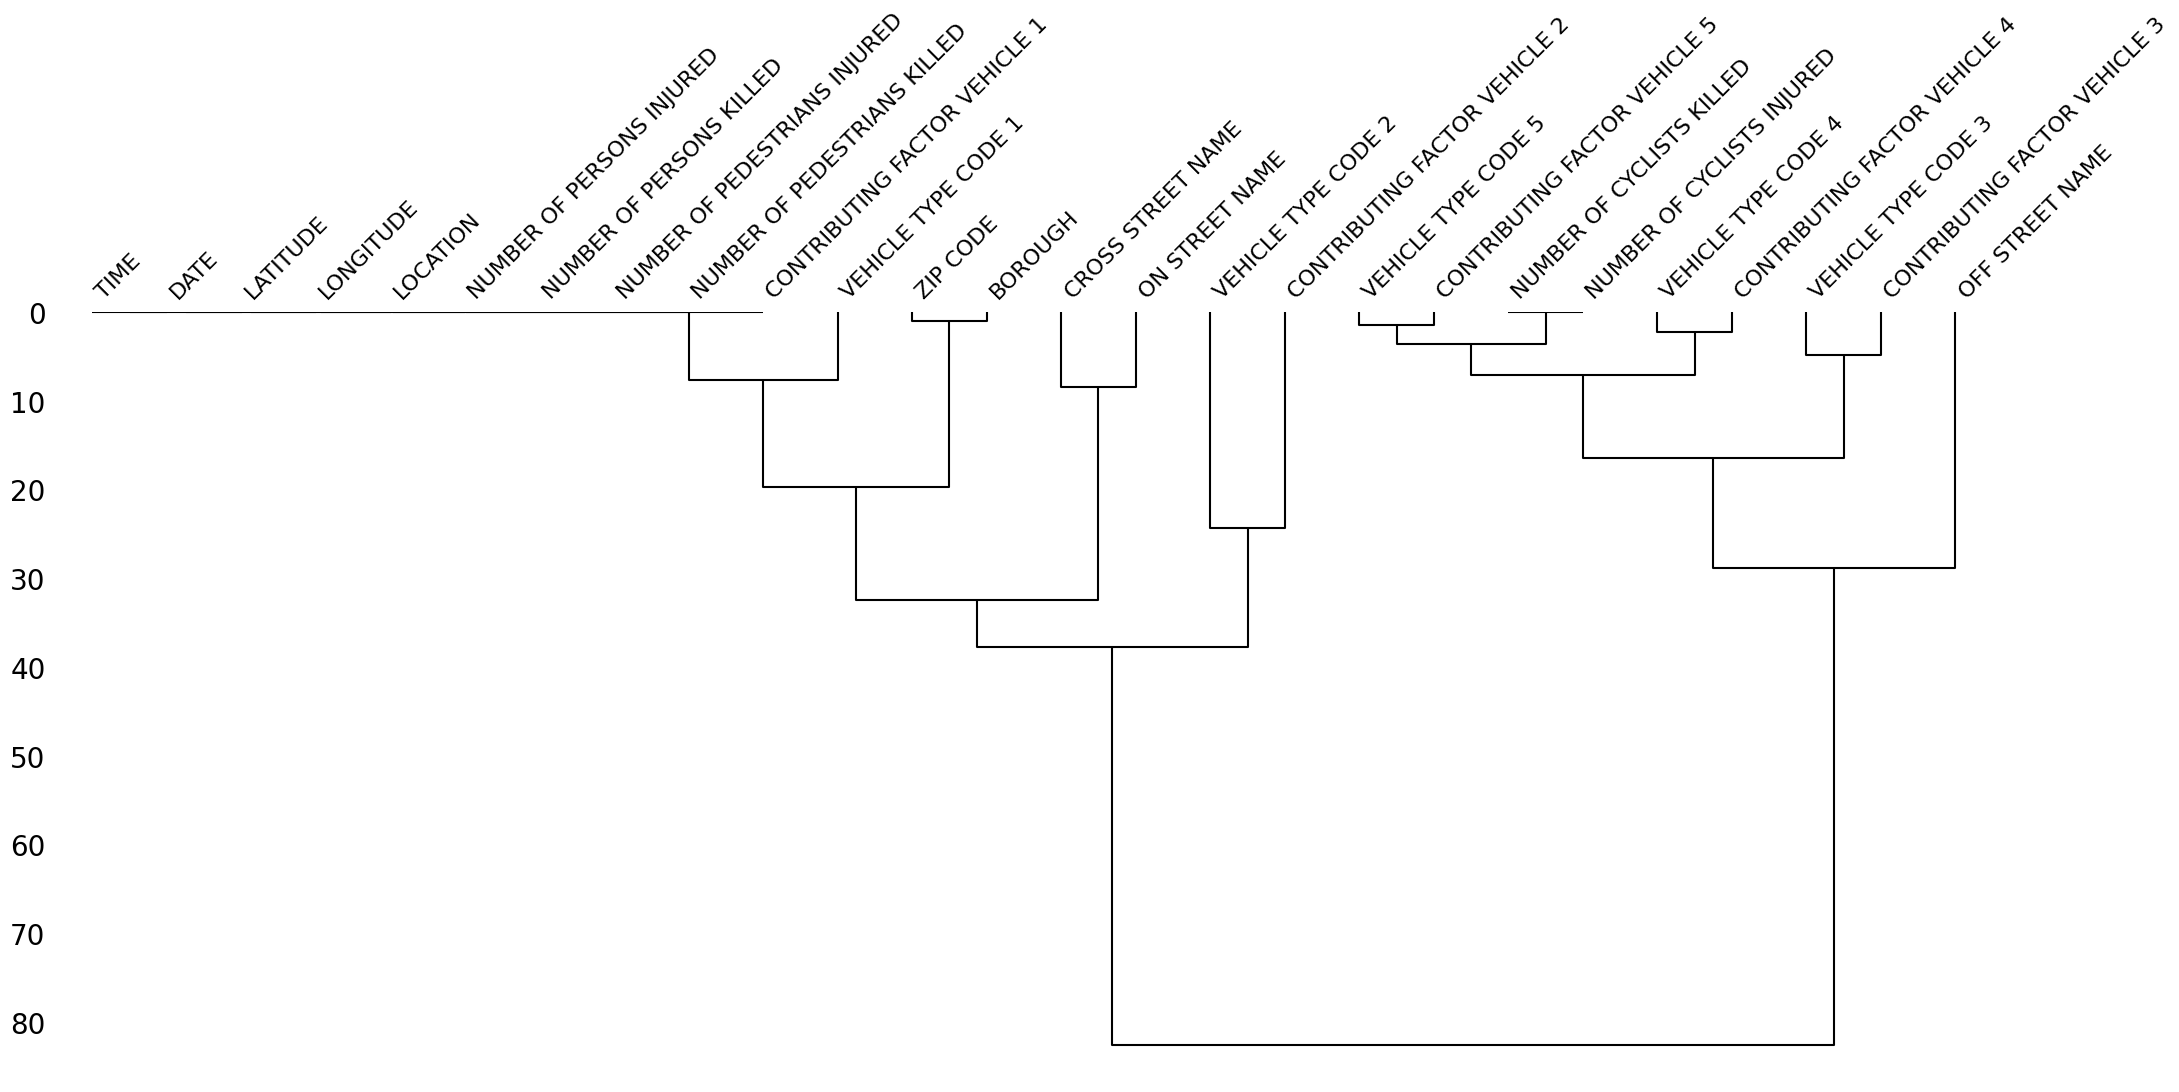

In [66]:
msno.dendrogram(collisions)

### Penanganan Missing Values

In [67]:
# Contoh lain dari
from sklearn.impute import KNNImputer

In [68]:
# check kolom mana saja yang terdapat missing values
horse_health_data.isna().sum()

,0
id,0
surgery,0
age,0
hospital_number,0
rectal_temp,0
pulse,0
respiratory_rate,0
temp_of_extremities,39
peripheral_pulse,60
mucous_membrane,21


In [69]:
# Dengan simple imputer
sim_imputer = SimpleImputer(strategy="most_frequent")
# Dengan KNN
knn_imputer = KNNImputer(n_neighbors=3)

In [70]:
# Gunakan fit_transform untuk mengeksekusi imputer
num_feature_imputed1 = sim_imputer.fit_transform(num_feature)

## Duplicate Values Handling

In [71]:
# Cek dulu apakah ada nilai duplikat pada data
horse_health_data.duplicated().sum()

np.int64(0)

In [72]:
# Drop Duplikasi
horse_health_data.drop_duplicates(inplace=True)

## Normalisasi Data

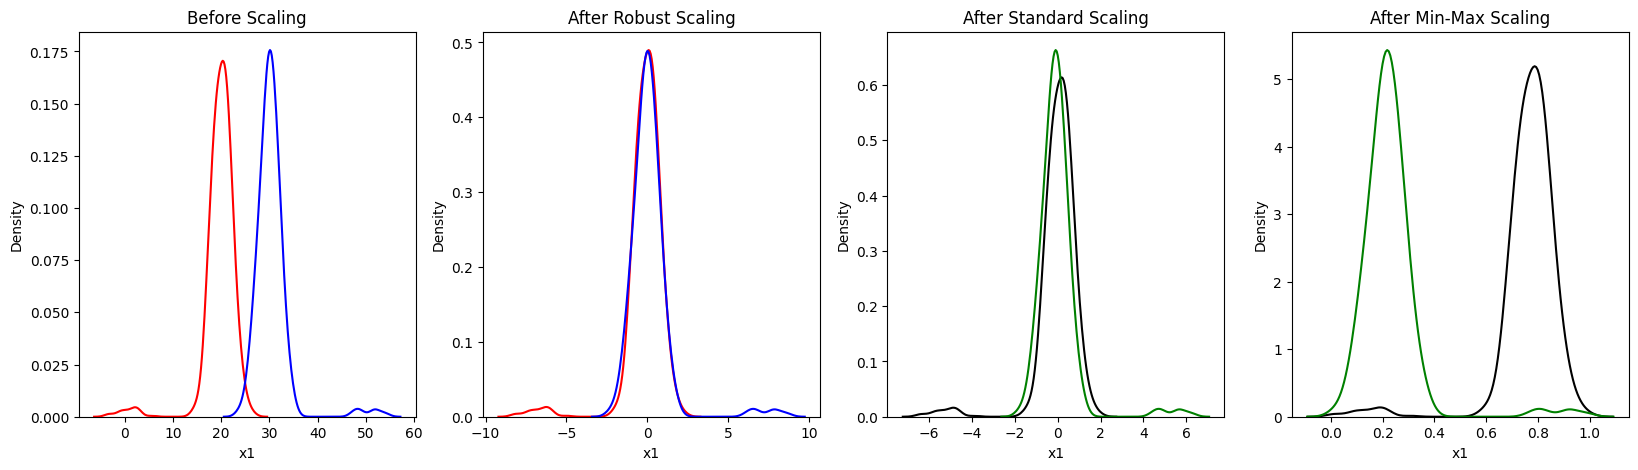

In [73]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

x = pd.DataFrame({
    'x1': np.concatenate([np.random.normal(20, 2, 1000), np.random.normal(1, 2, 25)]),
    'x2': np.concatenate([np.random.normal(30, 2, 1000), np.random.normal(50, 2, 25)]),
})
np.random.normal


scaler = RobustScaler()
robust_df = scaler.fit_transform(x)
robust_df = pd.DataFrame(robust_df, columns=['x1', 'x2'])


scaler = StandardScaler()
standard_df = scaler.fit_transform(x)
standard_df = pd.DataFrame(standard_df, columns=['x1', 'x2'])


scaler = MinMaxScaler()
minmax_df = scaler.fit_transform(x)
minmax_df = pd.DataFrame(minmax_df, columns=['x1', 'x2'])


fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(20, 5))
ax1.set_title('Before Scaling')
sns.kdeplot(x['x1'], ax=ax1, color='r')
sns.kdeplot(x['x2'], ax=ax1, color='b')
ax2.set_title('After Robust Scaling')
sns.kdeplot(robust_df['x1'], ax=ax2, color='red')
sns.kdeplot(robust_df['x2'], ax=ax2, color='blue')
ax3.set_title('After Standard Scaling')
sns.kdeplot(standard_df['x1'], ax=ax3, color='black')
sns.kdeplot(standard_df['x2'], ax=ax3, color='g')
ax4.set_title('After Min-Max Scaling')
sns.kdeplot(minmax_df['x1'], ax=ax4, color='black')
sns.kdeplot(minmax_df['x2'], ax=ax4, color='g')
plt.show()

Referensi:

https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/



Hal-hal lain yang mungkin bisa kalian pelajari lebih lanjut 🤯:
- Nilai apa yang terbaik untuk imputasi data?
- Apa itu Transformasi data?
- Apa itu Encoding?
- Apa itu outlier?
- dsb.

Pertanyaan-pertanyaan di atas akan dijawab di workshop selanjutnya! Semangat!🔥🔥🔥

Credit :
- https://www.cell.com/patterns/fulltext/S2666-3899(20)30189-6
- https://www.geeksforgeeks.org/what-is-line-plot/
- https://www.geeksforgeeks.org/stacked-percentage-bar-plot-in-matplotlib/
- https://www.institutedata.com/blog/data-visualisation-principles-and-practices/
- https://www.studysmarter.co.uk/explanations/math/probability-and-statistics/charts-and-diagrams/ <br>

Another tools data visualization with python :
- https://altair-viz.github.io/ (for paper purpose)
- https://plotly.com/python/ (interactive)
- https://dash.plotly.com/ (dashboard with plotly)